In [8]:
#!/usr/bin/env python3
"""
Compute (1) cumulative mean latency vs departures (+ 95% CI across runs),
(2) throughput over time (binned) and
(3) steady-state throughput per run (+ 95% CI across runs)

Folder layout:
data/
  runA/summary.csv
  runB/summary.csv
  ...

CSV columns expected (at least):
ts_start, ts_end, success, latency_ms
"""

from __future__ import annotations

import os
from pathlib import Path
from dataclasses import dataclass
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# -----------------------
# Config you may change
# -----------------------
# DATA_DIR = Path("Crash1UniformRandom")
DATA_DIR = Path("./")
SUCCESS_ONLY = True

# Warm-up: choose ONE of these approaches
WARMUP_SECONDS = 10.0        # fixed warm-up time in seconds since run start
# WARMUP_SECONDS = None      # if None, we won't apply warm-up for steady-state throughput

BIN_SECONDS = 1.0            # throughput(t) bin size
T_ALPHA = 0.05               # 95% CI

# Student-t critical values (small n). For n=10 runs -> df=9 -> 2.262 (95% two-sided).
# If you use a different n, we fall back to normal approx (1.96) to keep code dependency-free.
T_CRIT_TABLE = {
    1: np.nan,
    2: 12.706,  # df=1
    3: 4.303,   # df=2
    4: 3.182,   # df=3
    5: 2.776,   # df=4
    6: 2.571,   # df=5
    7: 2.447,   # df=6
    8: 2.365,   # df=7
    9: 2.306,   # df=8
    10: 2.262,  # df=9
    11: 2.228,  # df=10
}


def t_crit_95(n: int) -> float:
    """Two-sided 95% t critical value for sample size n (df=n-1)."""
    if n in T_CRIT_TABLE and not np.isnan(T_CRIT_TABLE[n]):
        return float(T_CRIT_TABLE[n])
    # fallback: normal approx
    return 1.96


@dataclass
class RunSeries:
    name: str
    # time since run start for each completion (seconds), sorted by completion time
    end_s: np.ndarray
    # latency_ms aligned with end_s
    lat_ms: np.ndarray
    # cumulative mean latency by departure index (1..n)
    cum_mean_lat: np.ndarray


def load_run(run_dir: Path) -> RunSeries:
    csv_path = run_dir / "summary.csv"
    if not csv_path.exists():
        raise FileNotFoundError(f"Missing {csv_path}")

    df = pd.read_csv(csv_path)

    # Basic validation
    required = {"ts_start", "ts_end", "success", "latency_ms"}
    missing = required - set(df.columns)
    if missing:
        raise ValueError(f"{csv_path} missing columns: {missing}")

    if SUCCESS_ONLY:
        df = df[df["success"] == True].copy()

    # Parse timestamps
    df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
    df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    df = df.dropna(subset=["ts_end", "ts_start", "latency_ms"])

    # Sort by completion time
    df = df.sort_values("ts_end")

    # Define run start (earliest observed start)
    run_start = df["ts_start"].min()
    end_s = (df["ts_end"] - run_start).dt.total_seconds().to_numpy(dtype=float)

    lat_ms = df["latency_ms"].to_numpy(dtype=float)

    # cumulative mean latency by departure index
    cum_mean = np.cumsum(lat_ms) / np.arange(1, len(lat_ms) + 1)

    return RunSeries(name=run_dir.name, end_s=end_s, lat_ms=lat_ms, cum_mean_lat=cum_mean)


def list_runs(data_dir: Path) -> list[Path]:
    if not data_dir.exists():
        raise FileNotFoundError(f"Data dir not found: {data_dir.resolve()}")
    run_dirs = [p for p in data_dir.iterdir() if p.is_dir() and (p / "summary.csv").exists()]
    run_dirs.sort(key=lambda p: p.name)
    if not run_dirs:
        raise FileNotFoundError(f"No run folders with summary.csv found under {data_dir.resolve()}")
    return run_dirs


def ci_mean(values: np.ndarray) -> tuple[float, float]:
    """Return (mean, halfwidth) 95% CI using t across independent values."""
    values = np.asarray(values, dtype=float)
    n = len(values)
    m = float(np.mean(values))
    if n <= 1:
        return m, float("nan")
    s = float(np.std(values, ddof=1))
    half = t_crit_95(n) * (s / np.sqrt(n))
    return m, half


def compute_throughput_time_series(run: RunSeries, bin_seconds: float) -> tuple[np.ndarray, np.ndarray]:
    """
    Return (bin_centers_s, throughput_ops_s) for one run.
    Throughput computed from completions per bin.
    """
    if len(run.end_s) == 0:
        return np.array([]), np.array([])

    t_max = float(np.max(run.end_s))
    # Bin edges from 0 to ceil(t_max/bin)*bin
    n_bins = int(np.ceil(t_max / bin_seconds))
    edges = np.linspace(0.0, n_bins * bin_seconds, n_bins + 1)

    counts, _ = np.histogram(run.end_s, bins=edges)
    thr = counts / bin_seconds
    centers = edges[:-1] + bin_seconds / 2.0
    return centers, thr


def main():
    run_dirs = list_runs(DATA_DIR)
    runs: list[RunSeries] = [load_run(p) for p in run_dirs]

    print(f"Loaded {len(runs)} runs from {DATA_DIR.resolve()}")
    for r in runs:
        print(f"  - {r.name}: {len(r.lat_ms)} successful completions")

    # -------------------------------
    # (A) Cumulative mean latency + CI
    # -------------------------------
    # Align by departures: truncate all runs to common length
    min_n = min(len(r.cum_mean_lat) for r in runs)
    if min_n < 5:
        print("Warning: very few samples per run; cumulative plot may be noisy.")

    cum_matrix = np.vstack([r.cum_mean_lat[:min_n] for r in runs])  # shape: (n_runs, min_n)
    cum_mean = np.mean(cum_matrix, axis=0)
    # CI across runs at each departure index
    n_runs = len(runs)
    tcrit = t_crit_95(n_runs)
    cum_std = np.std(cum_matrix, axis=0, ddof=1) if n_runs > 1 else np.zeros(min_n)
    cum_half = tcrit * (cum_std / np.sqrt(n_runs)) if n_runs > 1 else np.full(min_n, np.nan)

    x_dep = np.arange(1, min_n + 1)

    plt.figure()
    plt.plot(x_dep, cum_mean)
    plt.fill_between(x_dep, cum_mean - cum_half, cum_mean + cum_half, alpha=0.2)
    plt.xlabel("Number of departures (completed ops)")
    plt.ylabel("Cumulative mean latency (ms)")
    plt.title("Cumulative mean latency across runs (95% CI across runs)")
    plt.tight_layout()
    plt.show()

    # ------------------------------------
    # (A2) Cumulative average throughput + CI
    # ------------------------------------
    # For each run:
    #   T_hat(k) = k / t_k
    # where:
    #   k = departure index
    #   t_k = time of k-th completion (seconds since run start)

    # First, find common number of departures across runs
    min_n_thr = min(len(r.end_s) for r in runs)
    if min_n_thr < 5:
        print("Warning: very few samples for cumulative throughput.")

    thr_matrix = []

    for r in runs:
        # Use only up to min_n_thr completions
        t_k = r.end_s[:min_n_thr]

        # Avoid division by zero for first sample
        t_k = np.where(t_k <= 0.0, 1e-9, t_k)

        k = np.arange(1, min_n_thr + 1)
        cum_thr = k / t_k   # ops per second

        thr_matrix.append(cum_thr)

    thr_matrix = np.vstack(thr_matrix)  # shape: (n_runs, min_n_thr)

    thr_mean = np.mean(thr_matrix, axis=0)

    n_runs = len(runs)
    tcrit = t_crit_95(n_runs)

    if n_runs > 1:
        thr_std = np.std(thr_matrix, axis=0, ddof=1)
        thr_half = tcrit * (thr_std / np.sqrt(n_runs))
    else:
        thr_half = np.full(min_n_thr, np.nan)

    x_dep_thr = np.arange(1, min_n_thr + 1)

    plt.figure()
    plt.plot(x_dep_thr, thr_mean)
    plt.fill_between(
        x_dep_thr,
        thr_mean - thr_half,
        thr_mean + thr_half,
        alpha=0.2
    )
    plt.xlabel("Number of departures (completed ops)")
    plt.ylabel("Cumulative average throughput (ops/s)")
    plt.title("Cumulative average throughput across runs (95% CI)")
    plt.tight_layout()
    plt.show()

    # ------------------------------------
    # (B) Throughput over time (per run)
    # ------------------------------------
    # Plot a representative run (first run) for simplicity
    rep = runs[0]
    centers, thr = compute_throughput_time_series(rep, BIN_SECONDS)
    if len(centers) > 0:
        plt.figure()
        plt.plot(centers, thr)
        plt.xlabel("Time since run start (s)")
        plt.ylabel("Throughput (ops/s)")
        plt.title(f"Throughput over time (bin={BIN_SECONDS}s) - run {rep.name}")
        plt.tight_layout()
        plt.show()

    # ------------------------------------
    # (C) Steady-state throughput per run + CI
    # ------------------------------------
    throughputs = []
    for r in runs:
        if len(r.end_s) == 0:
            throughputs.append(np.nan)
            continue

        t_end = float(np.max(r.end_s))
        if WARMUP_SECONDS is None:
            t0 = 0.0
        else:
            t0 = float(WARMUP_SECONDS)

        if t_end <= t0:
            throughputs.append(np.nan)
            continue

        n_after = int(np.sum(r.end_s >= t0))
        duration = t_end - t0
        throughputs.append(n_after / duration)

    throughputs = np.array(throughputs, dtype=float)
    valid = np.isfinite(throughputs)
    if np.sum(valid) == 0:
        print("No valid steady-state throughput values (check WARMUP_SECONDS).")
        return

    mean_thr, half_thr = ci_mean(throughputs[valid])
    print("\nSteady-state throughput (ops/s) per run:")
    for r, t in zip(runs, throughputs):
        print(f"  {r.name}: {t:.3f}" if np.isfinite(t) else f"  {r.name}: NaN")

    print(f"\nMean throughput = {mean_thr:.3f} ops/s")
    print(f"95% CI half-width = {half_thr:.3f} ops/s")
    if WARMUP_SECONDS is not None:
        print(f"(Warm-up removed: first {WARMUP_SECONDS}s)")

    # Plot per-run throughput with CI
    plt.figure()
    x = np.arange(len(runs))
    plt.scatter(x, throughputs)
    plt.axhline(mean_thr, linestyle="--")
    plt.fill_between(
        [-0.5, len(runs) - 0.5],
        [mean_thr - half_thr, mean_thr - half_thr],
        [mean_thr + half_thr, mean_thr + half_thr],
        alpha=0.15,
    )
    plt.xticks(x, [r.name for r in runs], rotation=45, ha="right")
    plt.ylabel("Steady-state throughput (ops/s)")
    plt.title("Steady-state throughput per run (+ mean and 95% CI across runs)")
    plt.tight_layout()
    plt.show()



Time slots identified: 5
  Slot 0: Before maintenance [0.0s - 119.5s]
  Slot 1: Between maint 1 [119.6s - 239.6s]
  Slot 2: Between maint 2 [242.5s - 362.5s]
  Slot 3: Between maint 3 [375.1s - 495.1s]
  Slot 4: After maintenance [508.2s - 620.1s]


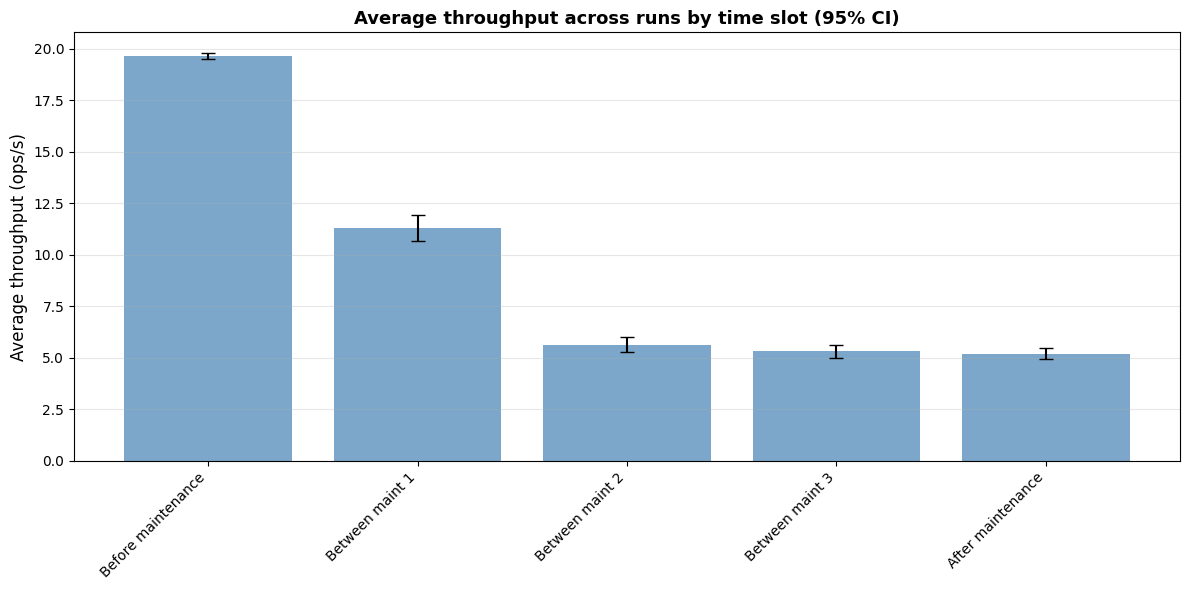


Average throughput by slot:
  Before maintenance: 19.658 ± 0.142 ops/s
  Between maint 1: 11.275 ± 0.628 ops/s
  Between maint 2: 5.622 ± 0.371 ops/s
  Between maint 3: 5.317 ± 0.315 ops/s
  After maintenance: 5.193 ± 0.281 ops/s


In [9]:
# Plot average throughput across runs with maintenance-aware time alignment
DATA_DIR = Path("Crash2UniformContigous")
run_dirs = list_runs(DATA_DIR)
runs_data = []

# First, collect maintenance events and throughput data for each run
for run_dir in run_dirs:
    csv_path = run_dir / "summary.csv"
    df = pd.read_csv(csv_path)
    
    # Parse timestamps
    df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
    df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    run_start = df["ts_start"].min()
    
    # Get maintenance events
    maintenance_events = []
    if "op" in df.columns:
        maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
        maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
        
        if len(maint_start) > 0:
            maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds()
            maintenance_events.extend([("START", t) for t in maint_start["time_s"]])
        
        if len(maint_end) > 0:
            maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds()
            maintenance_events.extend([("END", t) for t in maint_end["time_s"]])
    
    # Sort maintenance events by time
    maintenance_events.sort(key=lambda x: x[1])
    
    # Load run series for throughput computation
    run = load_run(run_dir)
    
    runs_data.append({
        'name': run_dir.name,
        'run': run,
        'maintenance_events': maintenance_events
    })

# Define time slots based on maintenance events
# Slots: [0, first_START), [first_END, second_START), [second_END, third_START), ...
time_slots = []
slot_names = []

if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
    # Use first run's maintenance schedule as reference
    events = runs_data[0]['maintenance_events']
    
    # Slot 0: from start to first START_MAINTENANCE
    first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
    if first_start_idx is not None:
        time_slots.append((0.0, events[first_start_idx][1]))
        slot_names.append("Before maintenance")
        
        # Find subsequent END -> START pairs
        for i in range(len(events) - 1):
            if events[i][0] == "END" and events[i+1][0] == "START":
                time_slots.append((events[i][1], events[i+1][1]))
                slot_names.append(f"Between maint {len(time_slots)-1}")
        
        # If there's a final END, add slot from END to end of run
        last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
        if last_end_idx is not None:
            max_time = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
            time_slots.append((events[last_end_idx][1], max_time))
            slot_names.append("After maintenance")
else:
    # No maintenance events, use entire run
    max_time = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
    time_slots.append((0.0, max_time))
    slot_names.append("Full run")

print(f"Time slots identified: {len(time_slots)}")
for i, ((t_start, t_end), name) in enumerate(zip(time_slots, slot_names)):
    print(f"  Slot {i}: {name} [{t_start:.1f}s - {t_end:.1f}s]")

# Compute average throughput for each slot across runs
slot_throughputs = []

for slot_idx, (t_start, t_end) in enumerate(time_slots):
    slot_duration = t_end - t_start
    if slot_duration <= 0:
        continue
    
    # Compute throughput for this slot for each run
    run_throughputs = []
    for rd in runs_data:
        # Count completions in this time slot
        mask = (rd['run'].end_s >= t_start) & (rd['run'].end_s < t_end)
        n_ops = np.sum(mask)
        thr = n_ops / slot_duration
        run_throughputs.append(thr)
    
    # Compute mean and CI across runs
    mean_thr, half_thr = ci_mean(np.array(run_throughputs))
    slot_throughputs.append({
        'slot_name': slot_names[slot_idx],
        'mean': mean_thr,
        'ci_half': half_thr,
        't_start': t_start,
        't_end': t_end
    })

# Plot average throughput by slot
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(slot_throughputs))
means = [s['mean'] for s in slot_throughputs]
ci_halfs = [s['ci_half'] for s in slot_throughputs]
labels = [s['slot_name'] for s in slot_throughputs]

plt.bar(x_pos, means, yerr=ci_halfs, capsize=5, alpha=0.7, color='steelblue')
plt.xticks(x_pos, labels, rotation=45, ha='right')
plt.ylabel("Average throughput (ops/s)", fontsize=12)
plt.title("Average throughput across runs by time slot (95% CI)", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary
print("\nAverage throughput by slot:")
for s in slot_throughputs:
    print(f"  {s['slot_name']}: {s['mean']:.3f} ± {s['ci_half']:.3f} ops/s")

Time slots identified: 6
  Slot 0: Before maintenance [0.0s - 119.5s]
  Slot 1: Between maint 1 [119.6s - 239.7s]
  Slot 2: Between maint 2 [243.3s - 363.3s]
  Slot 3: Between maint 3 [367.6s - 487.6s]
  Slot 4: Between maint 4 [489.8s - 609.7s]
  Slot 5: After maintenance [612.9s - 620.2s]


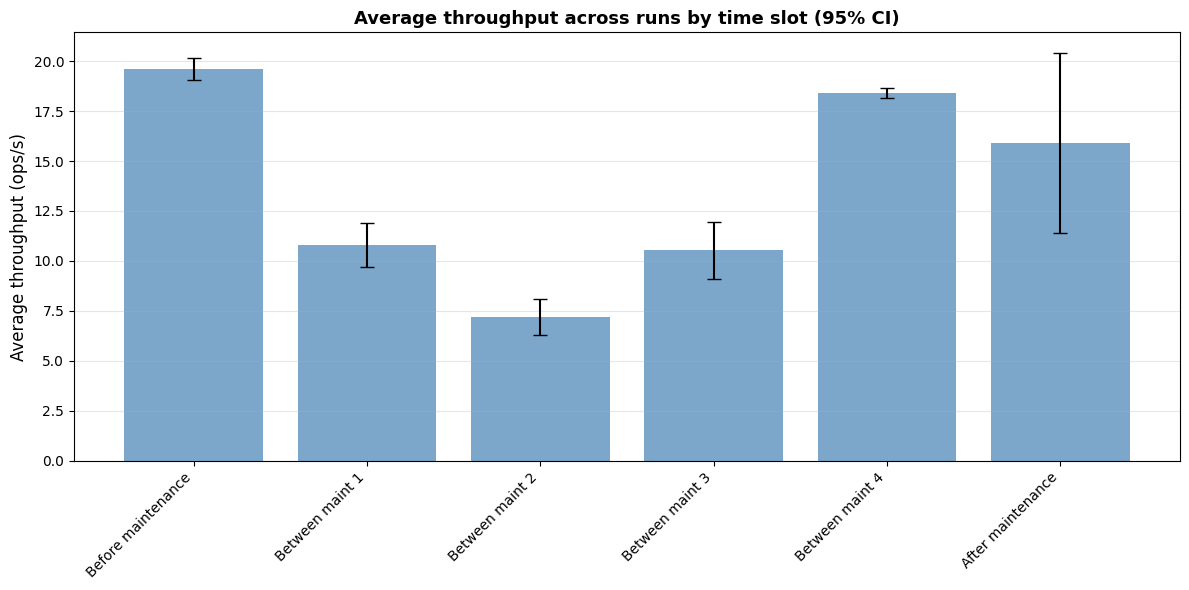


Average throughput by slot:
  Before maintenance: 19.610 ± 0.545 ops/s
  Between maint 1: 10.790 ± 1.091 ops/s
  Between maint 2: 7.187 ± 0.884 ops/s
  Between maint 3: 10.521 ± 1.437 ops/s
  Between maint 4: 18.415 ± 0.253 ops/s
  After maintenance: 15.910 ± 4.510 ops/s


In [10]:
# Plot average throughput across runs with maintenance-aware time alignment
DATA_DIR = Path("Crash2UniformNonContigous")
run_dirs = list_runs(DATA_DIR)
runs_data = []

# First, collect maintenance events and throughput data for each run
for run_dir in run_dirs:
    csv_path = run_dir / "summary.csv"
    df = pd.read_csv(csv_path)
    
    # Parse timestamps
    df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
    df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    run_start = df["ts_start"].min()
    
    # Get maintenance events
    maintenance_events = []
    if "op" in df.columns:
        maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
        maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
        
        if len(maint_start) > 0:
            maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds()
            maintenance_events.extend([("START", t) for t in maint_start["time_s"]])
        
        if len(maint_end) > 0:
            maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds()
            maintenance_events.extend([("END", t) for t in maint_end["time_s"]])
    
    # Sort maintenance events by time
    maintenance_events.sort(key=lambda x: x[1])
    
    # Load run series for throughput computation
    run = load_run(run_dir)
    
    runs_data.append({
        'name': run_dir.name,
        'run': run,
        'maintenance_events': maintenance_events
    })

# Define time slots based on maintenance events
# Slots: [0, first_START), [first_END, second_START), [second_END, third_START), ...
time_slots = []
slot_names = []

if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
    # Use first run's maintenance schedule as reference
    events = runs_data[0]['maintenance_events']
    
    # Slot 0: from start to first START_MAINTENANCE
    first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
    if first_start_idx is not None:
        time_slots.append((0.0, events[first_start_idx][1]))
        slot_names.append("Before maintenance")
        
        # Find subsequent END -> START pairs
        for i in range(len(events) - 1):
            if events[i][0] == "END" and events[i+1][0] == "START":
                time_slots.append((events[i][1], events[i+1][1]))
                slot_names.append(f"Between maint {len(time_slots)-1}")
        
        # If there's a final END, add slot from END to end of run
        last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
        if last_end_idx is not None:
            max_time = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
            time_slots.append((events[last_end_idx][1], max_time))
            slot_names.append("After maintenance")
else:
    # No maintenance events, use entire run
    max_time = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
    time_slots.append((0.0, max_time))
    slot_names.append("Full run")

print(f"Time slots identified: {len(time_slots)}")
for i, ((t_start, t_end), name) in enumerate(zip(time_slots, slot_names)):
    print(f"  Slot {i}: {name} [{t_start:.1f}s - {t_end:.1f}s]")

# Compute average throughput for each slot across runs
slot_throughputs = []

for slot_idx, (t_start, t_end) in enumerate(time_slots):
    slot_duration = t_end - t_start
    if slot_duration <= 0:
        continue
    
    # Compute throughput for this slot for each run
    run_throughputs = []
    for rd in runs_data:
        # Count completions in this time slot
        mask = (rd['run'].end_s >= t_start) & (rd['run'].end_s < t_end)
        n_ops = np.sum(mask)
        thr = n_ops / slot_duration
        run_throughputs.append(thr)
    
    # Compute mean and CI across runs
    mean_thr, half_thr = ci_mean(np.array(run_throughputs))
    slot_throughputs.append({
        'slot_name': slot_names[slot_idx],
        'mean': mean_thr,
        'ci_half': half_thr,
        't_start': t_start,
        't_end': t_end
    })

# Plot average throughput by slot
plt.figure(figsize=(12, 6))
x_pos = np.arange(len(slot_throughputs))
means = [s['mean'] for s in slot_throughputs]
ci_halfs = [s['ci_half'] for s in slot_throughputs]
labels = [s['slot_name'] for s in slot_throughputs]

plt.bar(x_pos, means, yerr=ci_halfs, capsize=5, alpha=0.7, color='steelblue')
plt.xticks(x_pos, labels, rotation=45, ha='right')
plt.ylabel("Average throughput (ops/s)", fontsize=12)
plt.title("Average throughput across runs by time slot (95% CI)", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# Print summary
print("\nAverage throughput by slot:")
for s in slot_throughputs:
    print(f"  {s['slot_name']}: {s['mean']:.3f} ± {s['ci_half']:.3f} ops/s")

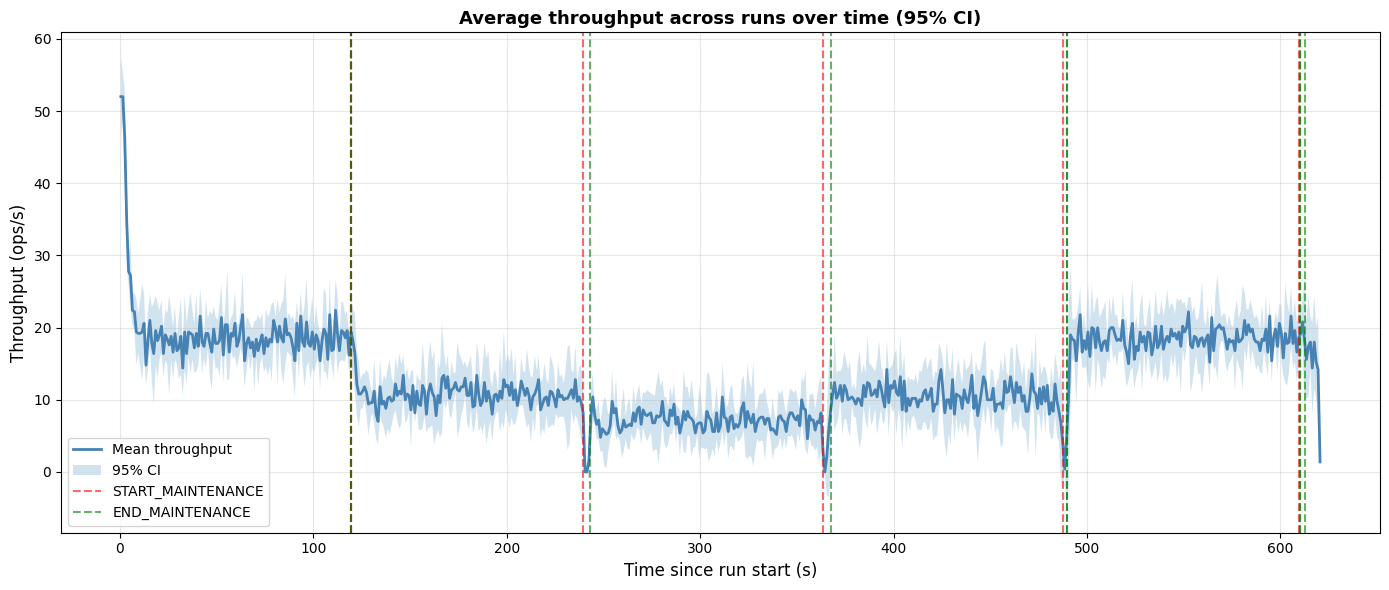

In [12]:
from matplotlib.patches import Patch

# Plot average throughput across runs over time with maintenance-aware time alignment
DATA_DIR = Path("Crash2UniformNonContigous")
run_dirs = list_runs(DATA_DIR)
runs_data = []

# First, collect maintenance events and throughput data for each run
for run_dir in run_dirs:
    csv_path = run_dir / "summary.csv"
    df = pd.read_csv(csv_path)
    
    # Parse timestamps
    df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
    df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
    run_start = df["ts_start"].min()
    
    # Get maintenance events
    maintenance_events = []
    if "op" in df.columns:
        maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
        maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
        
        if len(maint_start) > 0:
            maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds()
            maintenance_events.extend([("START", t) for t in maint_start["time_s"]])
        
        if len(maint_end) > 0:
            maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds()
            maintenance_events.extend([("END", t) for t in maint_end["time_s"]])
    
    # Sort maintenance events by time
    maintenance_events.sort(key=lambda x: x[1])
    
    # Load run series for throughput computation
    run = load_run(run_dir)
    
    runs_data.append({
        'name': run_dir.name,
        'run': run,
        'maintenance_events': maintenance_events
    })

# Build common time bins across all runs
max_t = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
n_bins = int(np.ceil(max_t / BIN_SECONDS))
edges = np.linspace(0.0, n_bins * BIN_SECONDS, n_bins + 1)
centers = edges[:-1] + BIN_SECONDS / 2.0

# Per-run throughput in each common bin
thr_matrix = []
for rd in runs_data:
    counts, _ = np.histogram(rd['run'].end_s, bins=edges)
    thr_matrix.append(counts / BIN_SECONDS)

thr_matrix = np.vstack(thr_matrix)  # shape: (n_runs, n_bins)

# Mean + 95% CI across runs
n_runs = thr_matrix.shape[0]
thr_mean = np.mean(thr_matrix, axis=0)

if n_runs > 1:
    thr_std = np.std(thr_matrix, axis=0, ddof=1)
    thr_half = t_crit_95(n_runs) * (thr_std / np.sqrt(n_runs))
else:
    thr_half = np.full_like(thr_mean, np.nan, dtype=float)

# Plot with maintenance events marked
plt.figure(figsize=(14, 6))
plt.plot(centers, thr_mean, linewidth=2, label="Mean throughput", color='steelblue')
plt.fill_between(centers, thr_mean - thr_half, thr_mean + thr_half, alpha=0.2, label="95% CI")

# Add maintenance event lines
if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
    events = runs_data[0]['maintenance_events']
    for op, t in events:
        if op == "START":
            plt.axvline(t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
        else:  # END
            plt.axvline(t, color='green', linestyle='--', linewidth=1.5, alpha=0.6)
    
    # Add legend entries for maintenance lines (use first occurrence)
    plt.axvline(events[0][1], color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='START_MAINTENANCE')
    plt.axvline(events[1][1], color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='END_MAINTENANCE')

plt.xlabel("Time since run start (s)", fontsize=12)
plt.ylabel("Throughput (ops/s)", fontsize=12)
plt.title("Average throughput across runs over time (95% CI)", fontsize=13, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.legend(loc='best')
plt.tight_layout()
plt.show()

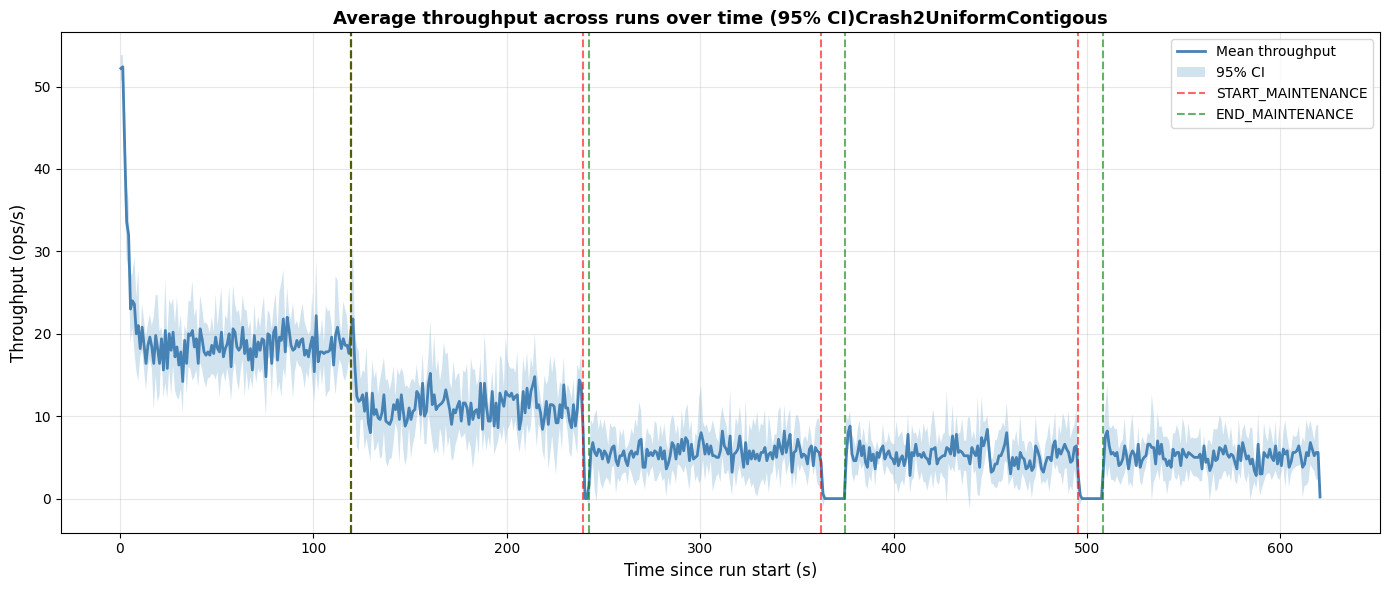

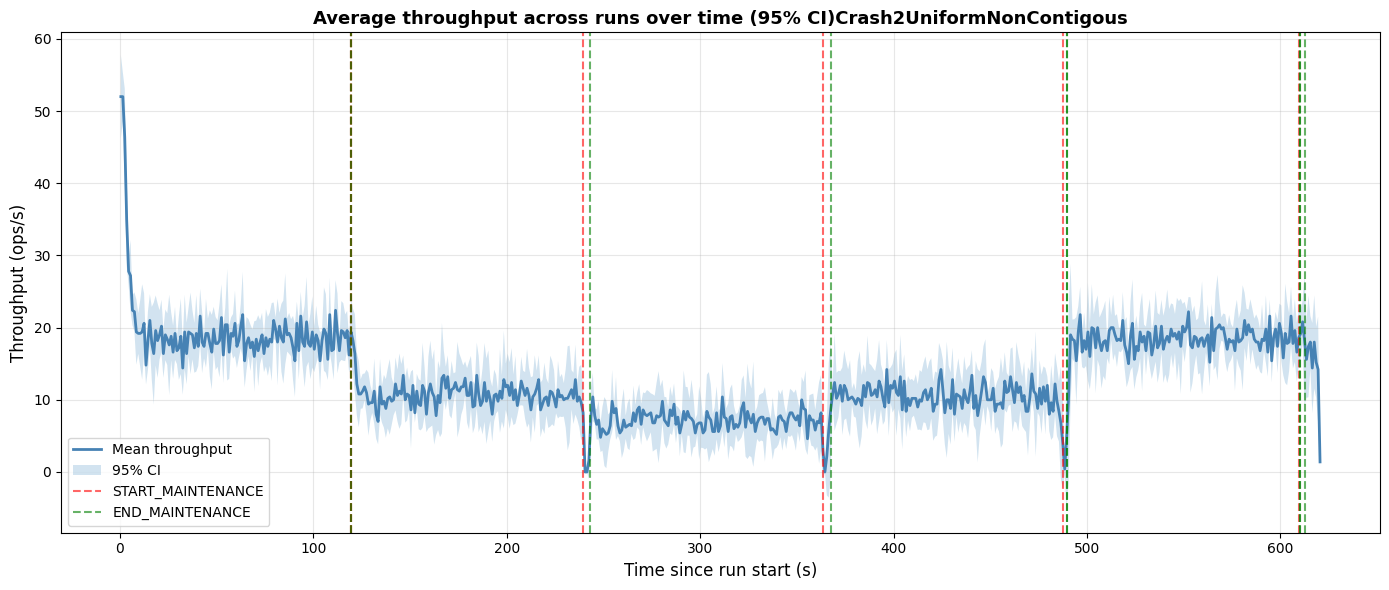

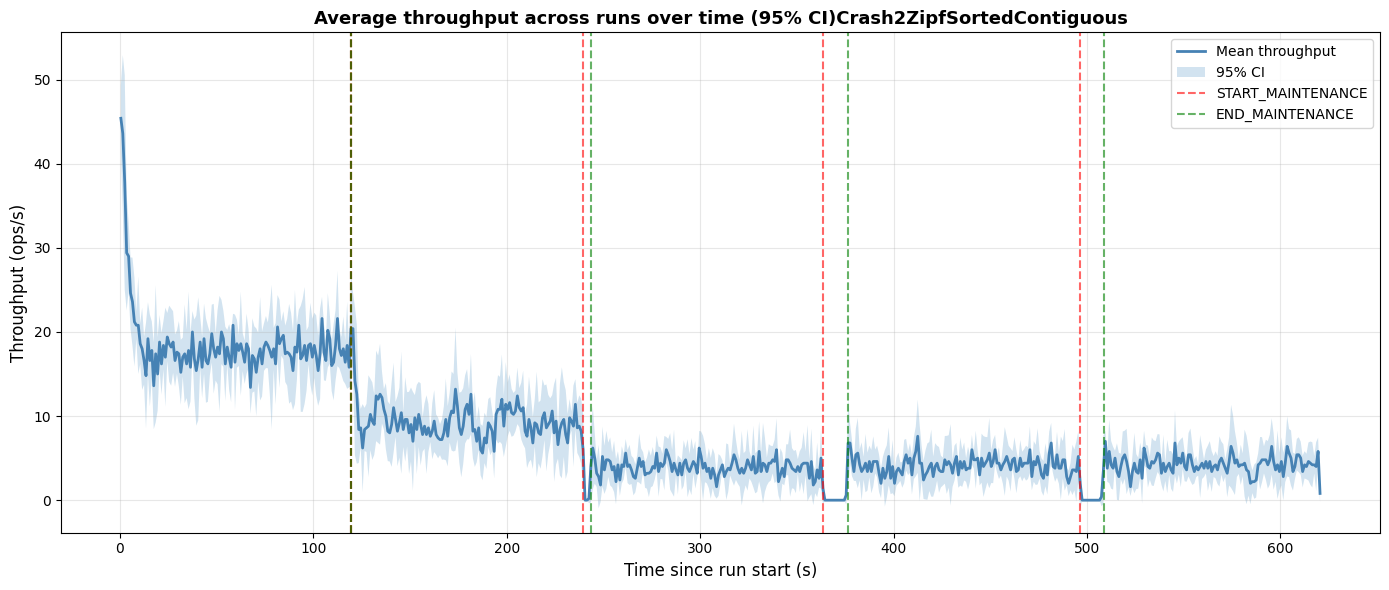

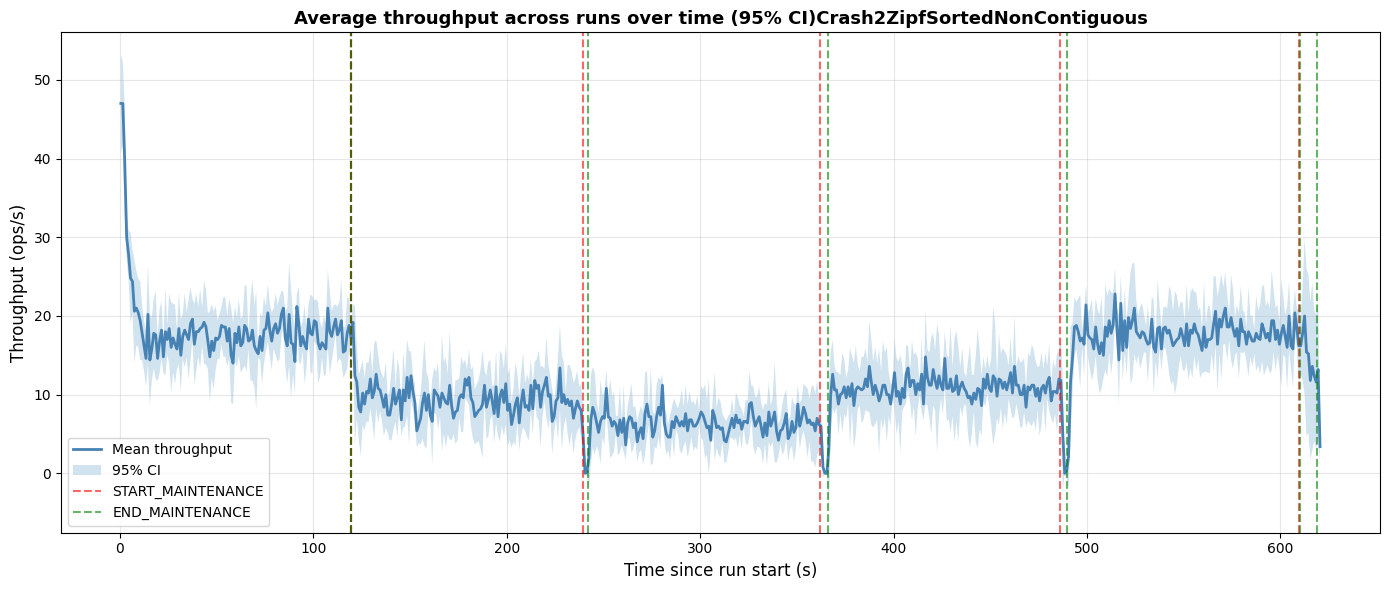

In [13]:
# Plot average throughput across runs over time with maintenance-aware time alignment
DATA_DIR = Path("./")

for dir in DATA_DIR.iterdir():
    if not dir.is_dir():
        continue
    runs_data = []
    # First, collect maintenance events and throughput data for each run
    for run_dir in dir.iterdir():
        if not run_dir.is_dir():
            continue
        csv_path = run_dir / "summary.csv"
        df = pd.read_csv(csv_path)
        
        # Parse timestamps
        df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
        run_start = df["ts_start"].min()
        
        # Get maintenance events
        maintenance_events = []
        if "op" in df.columns:
            maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
            maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
            
            if len(maint_start) > 0:
                maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds()
                maintenance_events.extend([("START", t) for t in maint_start["time_s"]])
            
            if len(maint_end) > 0:
                maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds()
                maintenance_events.extend([("END", t) for t in maint_end["time_s"]])
        
        # Sort maintenance events by time
        maintenance_events.sort(key=lambda x: x[1])
        
        # Load run series for throughput computation
        run = load_run(run_dir)
        
        runs_data.append({
            'name': run_dir.name,
            'run': run,
            'maintenance_events': maintenance_events
        })

    # Build common time bins across all runs
    if not runs_data or all(len(rd['run'].end_s) == 0 for rd in runs_data):
        continue
    
    max_t = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
    n_bins = int(np.ceil(max_t / BIN_SECONDS))
    edges = np.linspace(0.0, n_bins * BIN_SECONDS, n_bins + 1)
    centers = edges[:-1] + BIN_SECONDS / 2.0

    # Per-run throughput in each common bin
    thr_matrix = []
    for rd in runs_data:
        counts, _ = np.histogram(rd['run'].end_s, bins=edges)
        thr_matrix.append(counts / BIN_SECONDS)

    thr_matrix = np.vstack(thr_matrix)  # shape: (n_runs, n_bins)

    # Mean + 95% CI across runs
    n_runs = thr_matrix.shape[0]
    thr_mean = np.mean(thr_matrix, axis=0)

    if n_runs > 1:
        thr_std = np.std(thr_matrix, axis=0, ddof=1)
        thr_half = t_crit_95(n_runs) * (thr_std / np.sqrt(n_runs))
    else:
        thr_half = np.full_like(thr_mean, np.nan, dtype=float)

    # Plot with maintenance events marked
    plt.figure(figsize=(14, 6))
    plt.plot(centers, thr_mean, linewidth=2, label="Mean throughput", color='steelblue')
    plt.fill_between(centers, thr_mean - thr_half, thr_mean + thr_half, alpha=0.2, label="95% CI")

    # Add maintenance event lines
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        for op, t in events:
            if op == "START":
                plt.axvline(t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            else:  # END
                plt.axvline(t, color='green', linestyle='--', linewidth=1.5, alpha=0.6)
        
        # Add legend entries for maintenance lines (use first occurrence)
        plt.axvline(events[0][1], color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='START_MAINTENANCE')
        plt.axvline(events[1][1], color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='END_MAINTENANCE')

    plt.xlabel("Time since run start (s)", fontsize=12)
    plt.ylabel("Throughput (ops/s)", fontsize=12)
    plt.title("Average throughput across runs over time (95% CI)" + dir.name, fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

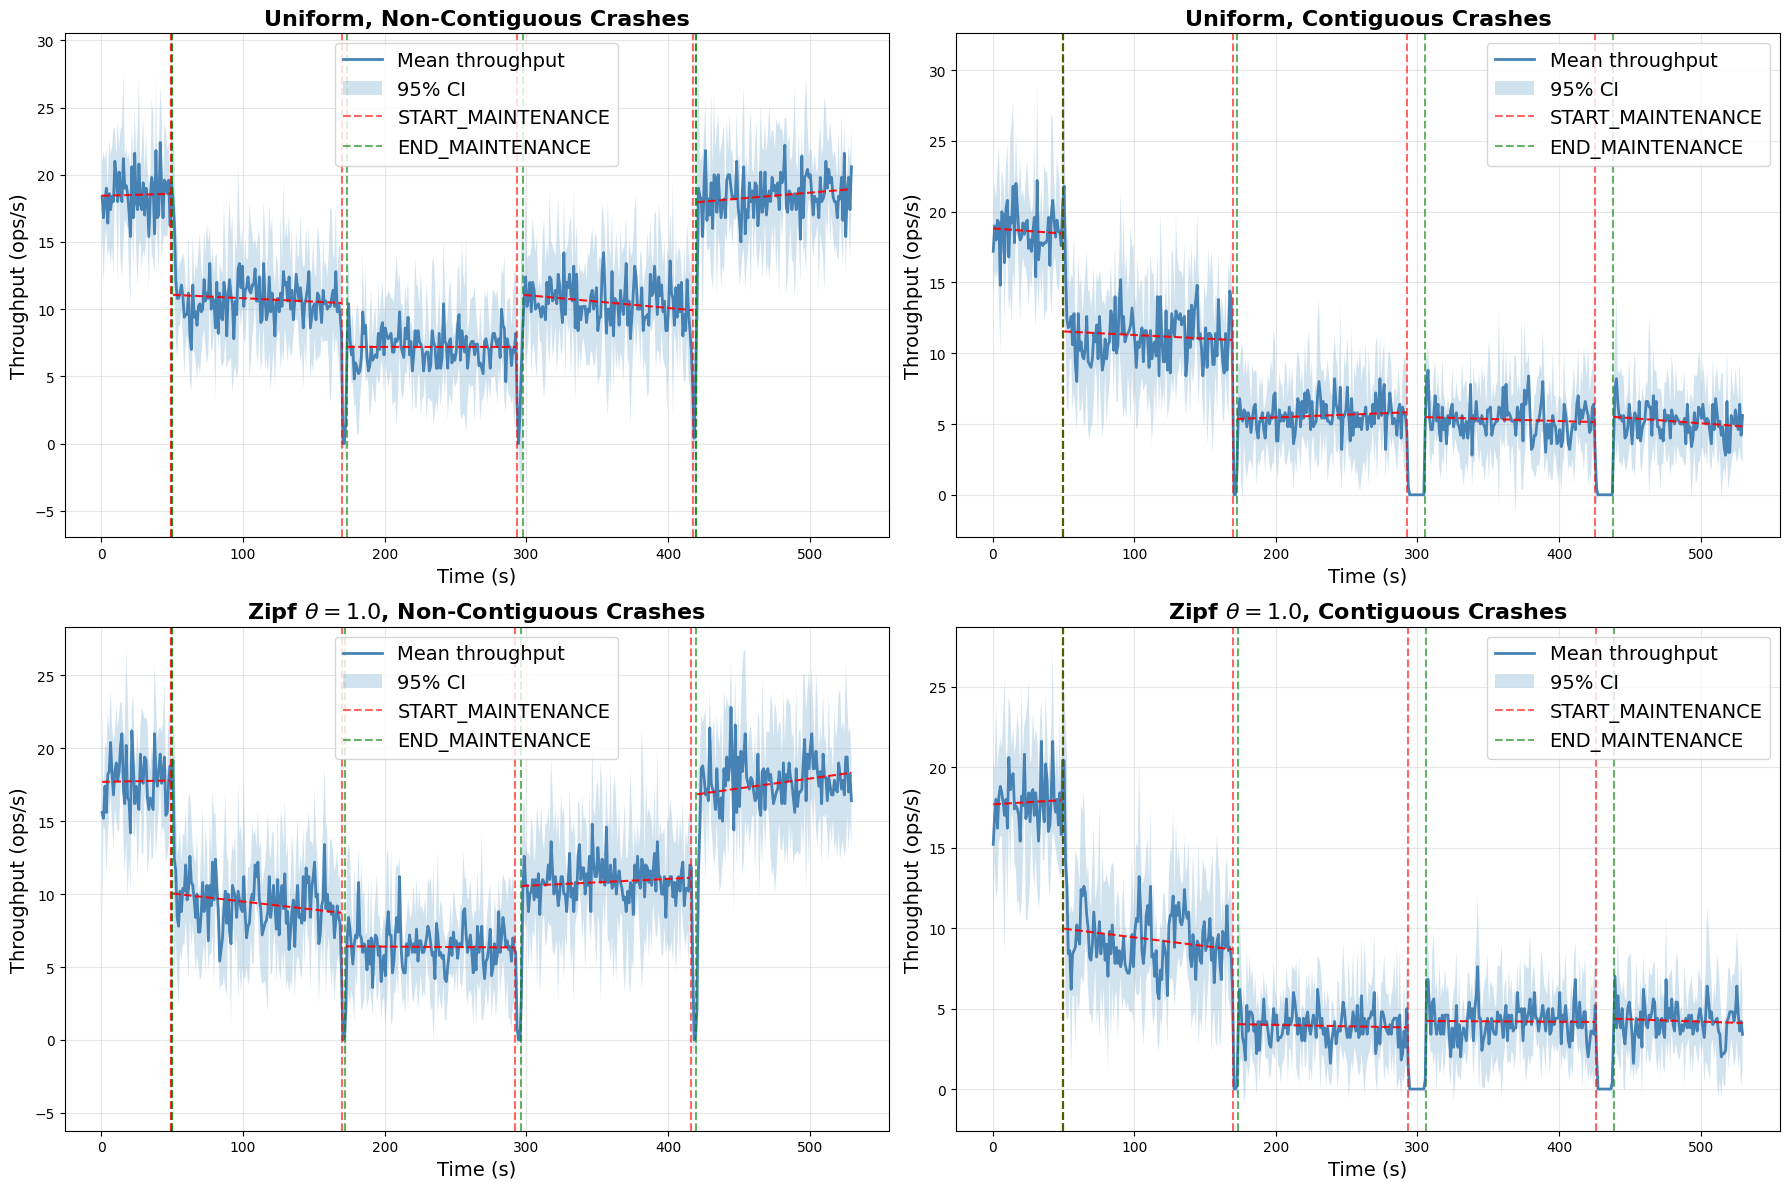

In [30]:
# Filter data: remove first 100 seconds and keep only up to 600 seconds
# Collect all directories first
all_dirs_data = []

# Add a mapping for configuration names
config_name_map = {
    'Crash2ZipfSorted2Contiguous': 'Zipf $\\theta=1.0$, Contiguous Crashes',
    'Crash2Uniform1NonContigous': 'Uniform, Non-Contiguous Crashes',
    'Crash2ZipfSorted1NonContiguous': 'Zipf $\\theta=1.0$, Non-Contiguous Crashes',
    'Crash2Uniform2Contigous': 'Uniform, Contiguous Crashes',
}

for dir in DATA_DIR.iterdir():
    if not dir.is_dir():
        continue
    runs_data = []
    # First, collect maintenance events and throughput data for each run
    for run_dir in dir.iterdir():
        if not run_dir.is_dir():
            continue
        csv_path = run_dir / "summary.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        
        # Parse timestamps
        df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
        run_start = df["ts_start"].min()
        
        # Get maintenance events
        maintenance_events = []
        if "op" in df.columns:
            maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
            maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
            
            if len(maint_start) > 0:
                maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds()
                maintenance_events.extend([("START", t) for t in maint_start["time_s"]])
            
            if len(maint_end) > 0:
                maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds()
                maintenance_events.extend([("END", t) for t in maint_end["time_s"]])
        
        # Sort maintenance events by time
        maintenance_events.sort(key=lambda x: x[1])
        
        # Load run series for throughput computation
        run = load_run(run_dir)
        
        # Filter: remove first 100s and keep only up to 600s
        mask = (run.end_s >= 70.0) & (run.end_s <= 600.0)
        run.end_s = run.end_s[mask] - 70.0  # Shift time by 70s
        run.lat_ms = run.lat_ms[mask]
        run.cum_mean_lat = np.cumsum(run.lat_ms) / np.arange(1, len(run.lat_ms) + 1)
        
        # Filter maintenance events similarly
        maintenance_events = [(op, t - 70.0) for op, t in maintenance_events if 70.0 <= t <= 600.0]
        
        runs_data.append({
            'name': run_dir.name,
            'run': run,
            'maintenance_events': maintenance_events
        })

    if not runs_data or all(len(rd['run'].end_s) == 0 for rd in runs_data):
        continue
    
    # Apply name mapping
    display_name = config_name_map.get(dir.name, dir.name)
    
    all_dirs_data.append({
        'dir_name': display_name,
        'runs_data': runs_data
    })

# Create a single figure with 4 subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, dir_data in enumerate(all_dirs_data):
    if idx >= 4:
        break
    
    ax = axes[idx]
    runs_data = dir_data['runs_data']
    dir_name = dir_data['dir_name']
    
    # Build common time bins across all runs
    max_t = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
    n_bins = int(np.ceil(max_t / BIN_SECONDS))
    edges = np.linspace(0.0, n_bins * BIN_SECONDS, n_bins + 1)
    centers = edges[:-1] + BIN_SECONDS / 2.0

    # Per-run throughput in each common bin
    thr_matrix = []
    for rd in runs_data:
        counts, _ = np.histogram(rd['run'].end_s, bins=edges)
        thr_matrix.append(counts / BIN_SECONDS)

    thr_matrix = np.vstack(thr_matrix)

    # Mean + 95% CI across runs
    n_runs = thr_matrix.shape[0]
    thr_mean = np.mean(thr_matrix, axis=0)

    if n_runs > 1:
        thr_std = np.std(thr_matrix, axis=0, ddof=1)
        thr_half = t_crit_95(n_runs) * (thr_std / np.sqrt(n_runs))
    else:
        thr_half = np.full_like(thr_mean, np.nan, dtype=float)

    # Plot with maintenance events marked
    ax.plot(centers, thr_mean, linewidth=2, label="Mean throughput", color='steelblue')
    ax.fill_between(centers, thr_mean - thr_half, thr_mean + thr_half, alpha=0.2, label="95% CI")

    # Add maintenance event lines
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        for event_op, t in events:
            if event_op == "START":
                ax.axvline(t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            else:
                ax.axvline(t, color='green', linestyle='--', linewidth=1.5, alpha=0.6)
        
        if len(events) > 0:
            ax.axvline(events[0][1], color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='START_MAINTENANCE')
        if len(events) > 1:
            ax.axvline(events[1][1], color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='END_MAINTENANCE')
    
        # Add phase-specific trend lines (excluding maintenance windows)
        maint_times = sorted([t for event_op, t in events])
        maint_intervals = [(maint_times[i], maint_times[i+1]) for i in range(0, len(maint_times), 2) if i+1 < len(maint_times)]
        phase_boundaries = [0] + maint_times + [centers[-1]]
        
        for i in range(len(phase_boundaries) - 1):
            phase_start = phase_boundaries[i]
            phase_end = phase_boundaries[i + 1]
            
            # Skip phases that are within maintenance windows
            is_maintenance = any(m_start <= phase_start and phase_end <= m_end for m_start, m_end in maint_intervals)
            if is_maintenance:
                continue
            
            # Find indices within this phase
            mask_phase = (centers >= phase_start) & (centers <= phase_end)
            if np.sum(mask_phase) > 1:
                x_phase = centers[mask_phase]
                y_phase = thr_mean[mask_phase]
                
                # Fit linear trend
                z = np.polyfit(x_phase, y_phase, 1)
                p = np.poly1d(z)
                ax.plot(x_phase, p(x_phase), '--', linewidth=1.5, alpha=0.9, color='red')

    ax.set_xlabel("Time (s)", fontsize=14)
    ax.set_ylabel("Throughput (ops/s)", fontsize=14)
    ax.set_title(dir_name, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3)
    ax.legend(loc='best', fontsize=14)

# plt.suptitle("Average throughput across runs over time (95% CI)", fontsize=14, fontweight='bold', y=0.995)
plt.tight_layout()
plt.savefig("crash_recovery.png")
plt.show()

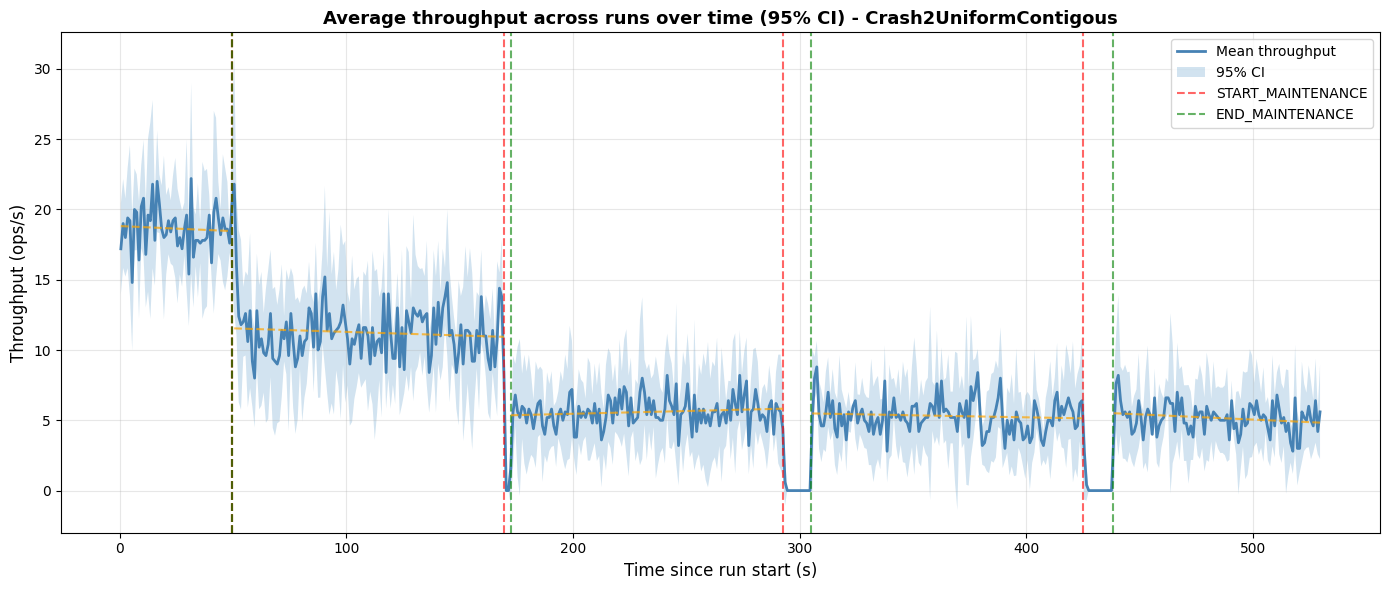

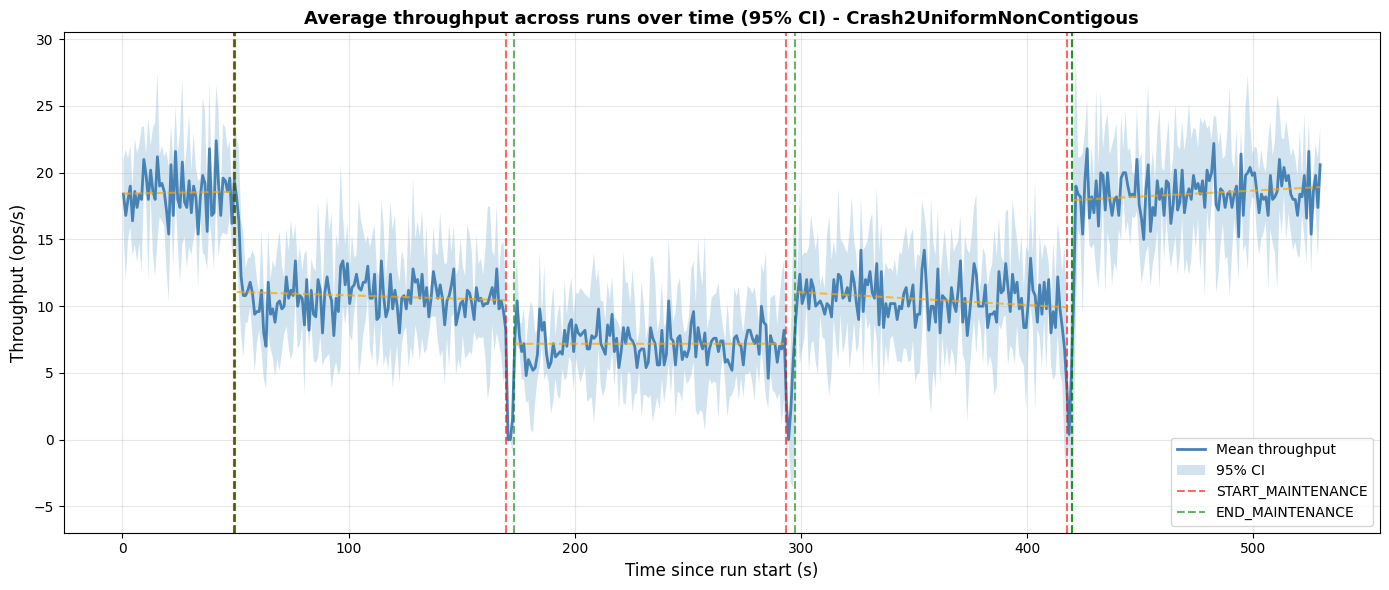

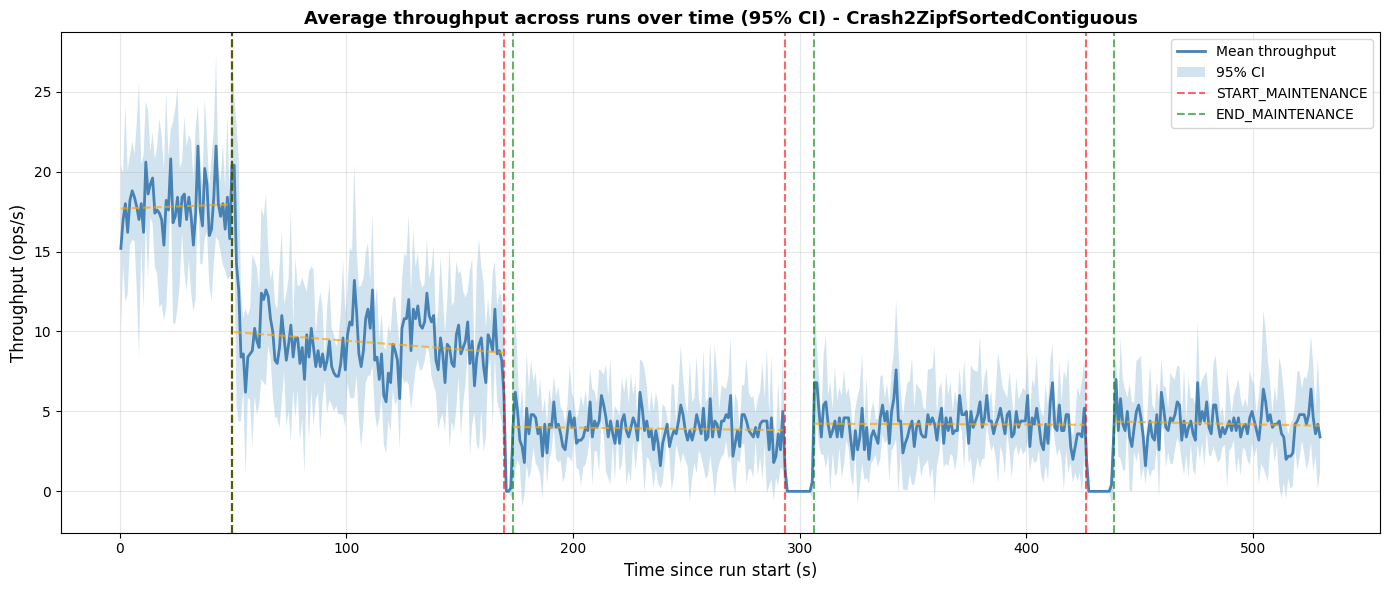

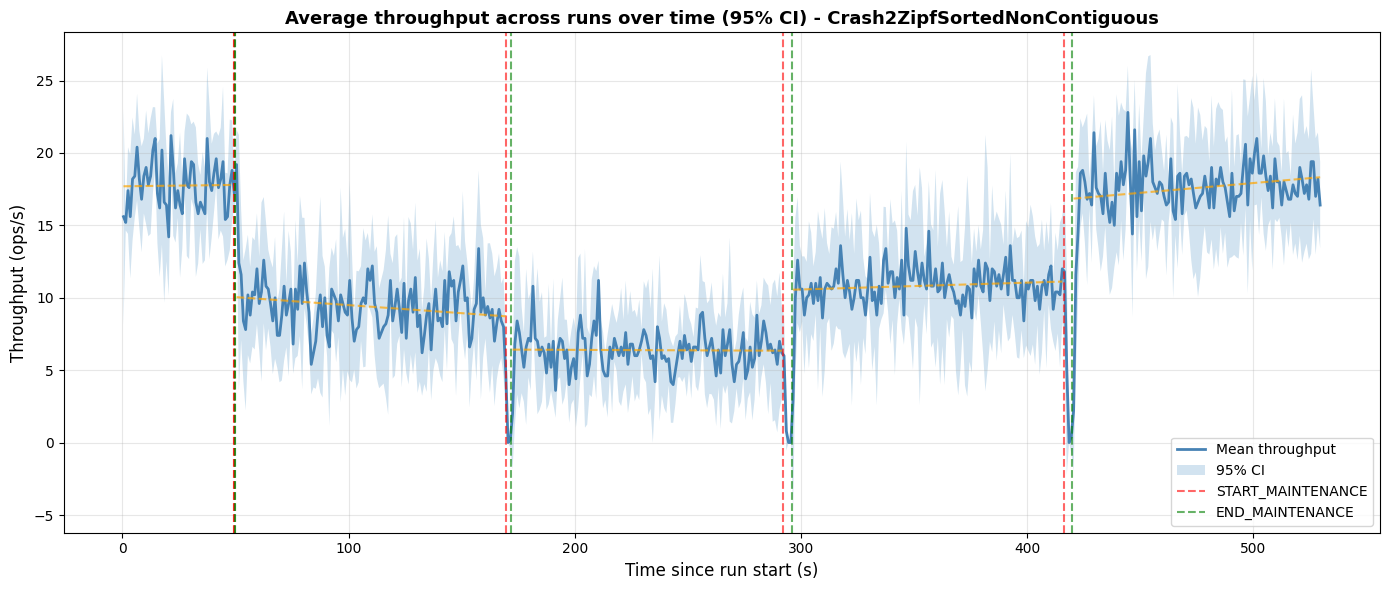

In [15]:
# Filter data: remove first 100 seconds and keep only up to 600 seconds
for dir in DATA_DIR.iterdir():
    if not dir.is_dir():
        continue
    runs_data = []
    # First, collect maintenance events and throughput data for each run
    for run_dir in dir.iterdir():
        if not run_dir.is_dir():
            continue
        csv_path = run_dir / "summary.csv"
        df = pd.read_csv(csv_path)
        
        # Parse timestamps
        df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
        run_start = df["ts_start"].min()
        
        # Get maintenance events
        maintenance_events = []
        if "op" in df.columns:
            maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
            maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
            
            if len(maint_start) > 0:
                maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds()
                maintenance_events.extend([("START", t) for t in maint_start["time_s"]])
            
            if len(maint_end) > 0:
                maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds()
                maintenance_events.extend([("END", t) for t in maint_end["time_s"]])
        
        # Sort maintenance events by time
        maintenance_events.sort(key=lambda x: x[1])
        
        # Load run series for throughput computation
        run = load_run(run_dir)
        
        # Filter: remove first 100s and keep only up to 600s
        mask = (run.end_s >= 70.0) & (run.end_s <= 600.0)
        run.end_s = run.end_s[mask] - 70.0  # Shift time by 70s
        run.lat_ms = run.lat_ms[mask]
        run.cum_mean_lat = np.cumsum(run.lat_ms) / np.arange(1, len(run.lat_ms) + 1)
        
        # Filter maintenance events similarly
        maintenance_events = [(op, t - 70.0) for op, t in maintenance_events if 70.0 <= t <= 600.0]
        
        runs_data.append({
            'name': run_dir.name,
            'run': run,
            'maintenance_events': maintenance_events
        })

    if not runs_data or all(len(rd['run'].end_s) == 0 for rd in runs_data):
        continue

    # Build common time bins across all runs
    max_t = max(float(np.max(rd['run'].end_s)) for rd in runs_data if len(rd['run'].end_s) > 0)
    n_bins = int(np.ceil(max_t / BIN_SECONDS))
    edges = np.linspace(0.0, n_bins * BIN_SECONDS, n_bins + 1)
    centers = edges[:-1] + BIN_SECONDS / 2.0

    # Per-run throughput in each common bin
    thr_matrix = []
    for rd in runs_data:
        counts, _ = np.histogram(rd['run'].end_s, bins=edges)
        thr_matrix.append(counts / BIN_SECONDS)

    thr_matrix = np.vstack(thr_matrix)

    # Mean + 95% CI across runs
    n_runs = thr_matrix.shape[0]
    thr_mean = np.mean(thr_matrix, axis=0)

    if n_runs > 1:
        thr_std = np.std(thr_matrix, axis=0, ddof=1)
        thr_half = t_crit_95(n_runs) * (thr_std / np.sqrt(n_runs))
    else:
        thr_half = np.full_like(thr_mean, np.nan, dtype=float)

    # Plot with maintenance events marked
    plt.figure(figsize=(14, 6))
    plt.plot(centers, thr_mean, linewidth=2, label="Mean throughput", color='steelblue')
    plt.fill_between(centers, thr_mean - thr_half, thr_mean + thr_half, alpha=0.2, label="95% CI")

    # Add maintenance event lines
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        for op, t in events:
            if op == "START":
                plt.axvline(t, color='red', linestyle='--', linewidth=1.5, alpha=0.6)
            else:
                plt.axvline(t, color='green', linestyle='--', linewidth=1.5, alpha=0.6)
        
        if len(events) > 0:
            plt.axvline(events[0][1], color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='START_MAINTENANCE')
        if len(events) > 1:
            plt.axvline(events[1][1], color='green', linestyle='--', linewidth=1.5, alpha=0.6, label='END_MAINTENANCE')
    
        # Add phase-specific trend lines (excluding maintenance windows)
        maint_times = sorted([t for op, t in events])
        maint_intervals = [(maint_times[i], maint_times[i+1]) for i in range(0, len(maint_times), 2) if i+1 < len(maint_times)]
        phase_boundaries = [0] + maint_times + [centers[-1]]
        
        for i in range(len(phase_boundaries) - 1):
            phase_start = phase_boundaries[i]
            phase_end = phase_boundaries[i + 1]
            
            # Skip phases that are within maintenance windows
            is_maintenance = any(m_start <= phase_start and phase_end <= m_end for m_start, m_end in maint_intervals)
            if is_maintenance:
                continue
            
            # Find indices within this phase
            mask_phase = (centers >= phase_start) & (centers <= phase_end)
            if np.sum(mask_phase) > 1:
                x_phase = centers[mask_phase]
                y_phase = thr_mean[mask_phase]
                
                # Fit linear trend
                z = np.polyfit(x_phase, y_phase, 1)
                p = np.poly1d(z)
                plt.plot(x_phase, p(x_phase), '--', linewidth=1.5, alpha=0.7, color='orange')

    plt.xlabel("Time since run start (s)", fontsize=12)
    plt.ylabel("Throughput (ops/s)", fontsize=12)
    plt.title("Average throughput across runs over time (95% CI) - " + dir.name, fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

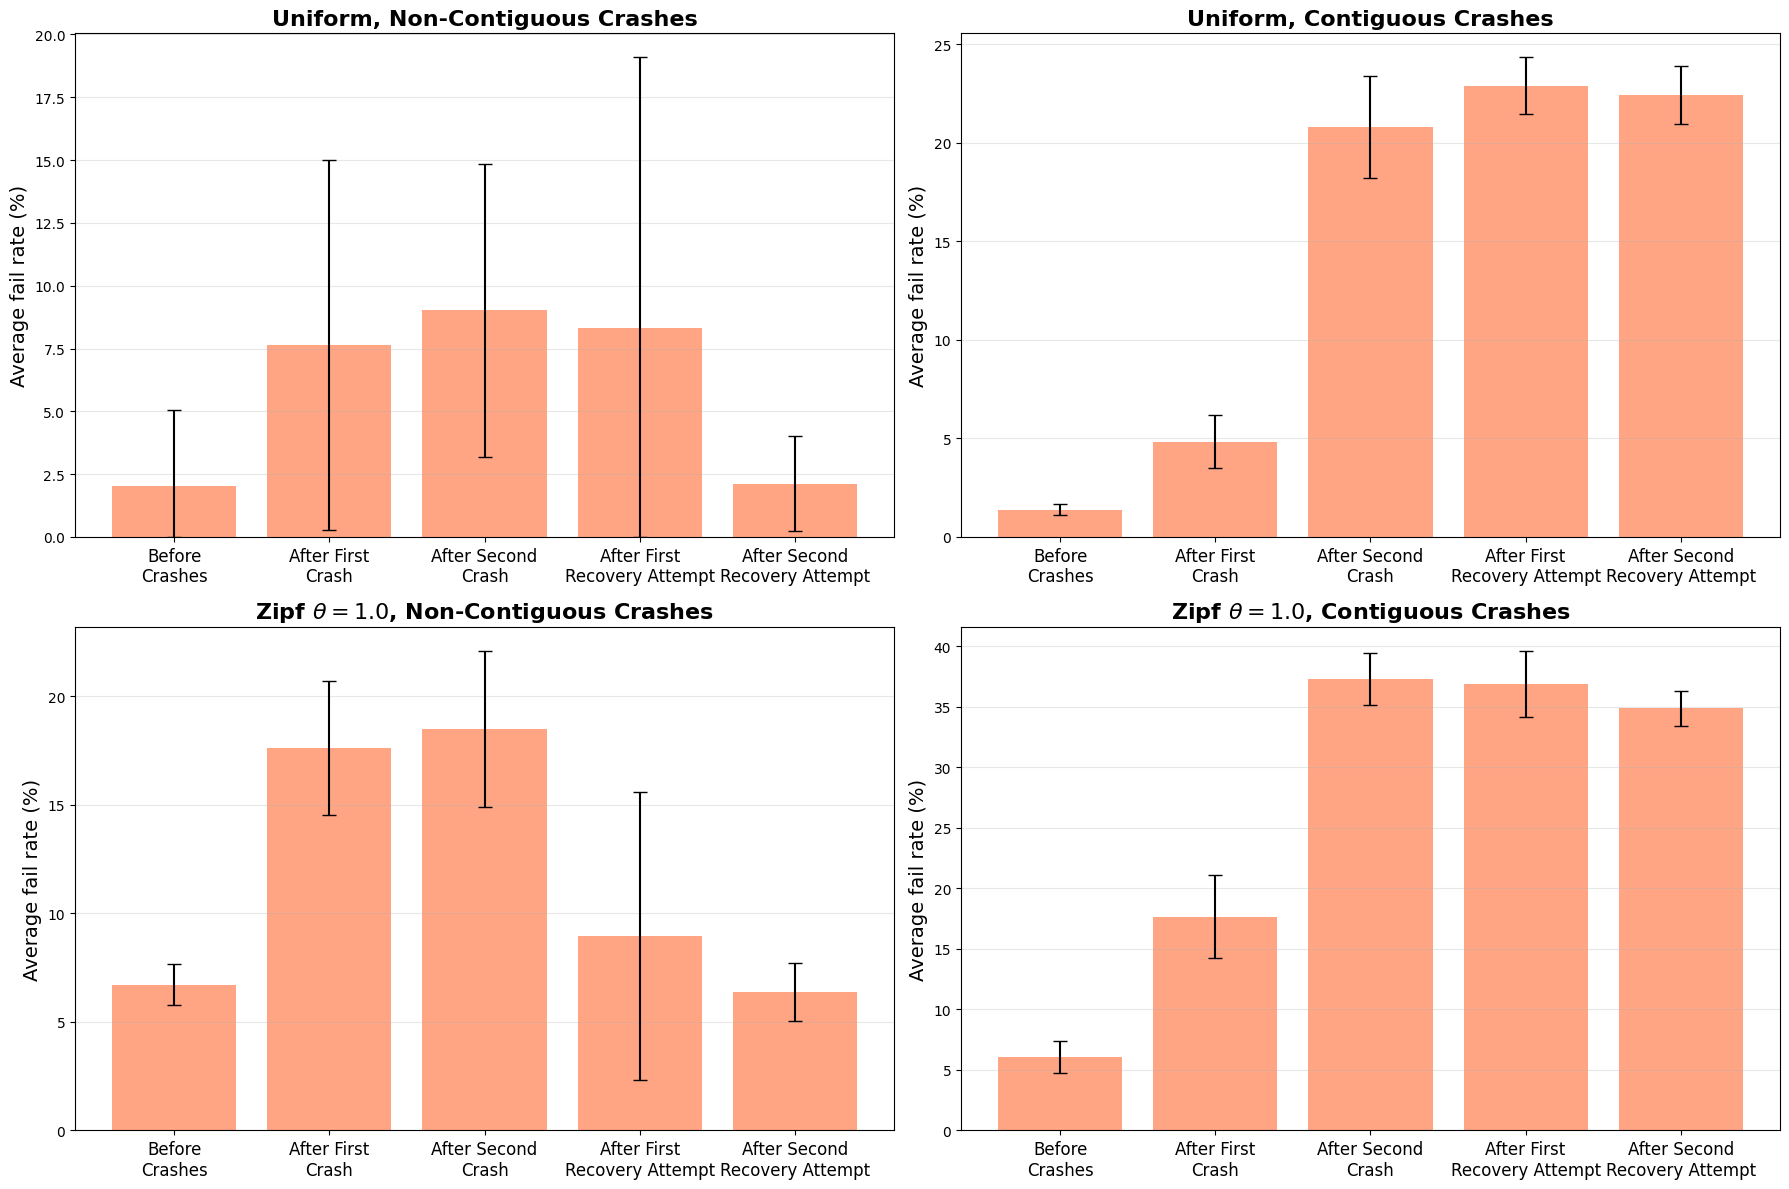

In [38]:
# Plot average fail rate across runs split by phases - Single figure with 4 subplots
all_dirs_fail_data = []

# Add a mapping for configuration names
config_name_map = {
    'Crash2ZipfSorted2Contiguous': 'Zipf $\\theta=1.0$, Contiguous Crashes',
    'Crash2Uniform1NonContigous': 'Uniform, Non-Contiguous Crashes',
    'Crash2ZipfSorted1NonContiguous': 'Zipf $\\theta=1.0$, Non-Contiguous Crashes',
    'Crash2Uniform2Contigous': 'Uniform, Contiguous Crashes',
}

# Customizable phase name mapping
# Edit these names to customize how phases appear in the plot
phase_name_map = {
    'before': 'Before\nCrashes',
    'between_1': 'After First\nCrash',
    'between_2': 'After Second\nCrash',
    'between_3': 'After First\nRecovery Attempt',
    'after': 'After Second\nRecovery Attempt',
    'full': 'Full Run'
}

# Helper function to get phase name from map
def get_phase_name(phase_type, phase_number=None):
    """Get phase name from the mapping"""
    if phase_type == "before":
        return phase_name_map.get('before', 'Before')
    elif phase_type == "between":
        key = f'between_{phase_number}'
        return phase_name_map.get(key, f"Between {phase_number}")
    elif phase_type == "after":
        return phase_name_map.get('after', 'After')
    else:
        return phase_name_map.get('full', 'Full Run')

for dir in DATA_DIR.iterdir():
    if not dir.is_dir():
        continue
    runs_data = []
    
    # Collect data for each run
    for run_dir in dir.iterdir():
        if not run_dir.is_dir():
            continue
        csv_path = run_dir / "summary.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        
        # Parse timestamps
        df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
        run_start = df["ts_start"].min()
        
        # Calculate time since run start
        df["time_s"] = (df["ts_end"] - run_start).dt.total_seconds()
        
        # Filter: remove first 70s and keep only up to 600s
        df_filtered = df[(df["time_s"] >= 70.0) & (df["time_s"] <= 600.0)].copy()
        df_filtered["time_s"] = df_filtered["time_s"] - 70.0
        
        # Get maintenance events
        maintenance_events = []
        if "op" in df.columns:
            maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
            maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
            
            if len(maint_start) > 0:
                maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds() - 70.0
                maintenance_events.extend([("START", t) for t in maint_start["time_s"] if 0 <= t <= 530])
            
            if len(maint_end) > 0:
                maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds() - 70.0
                maintenance_events.extend([("END", t) for t in maint_end["time_s"] if 0 <= t <= 530])
        
        maintenance_events.sort(key=lambda x: x[1])
        
        runs_data.append({
            'name': run_dir.name,
            'df': df_filtered,
            'maintenance_events': maintenance_events
        })
    
    if not runs_data:
        continue
    
    # Apply name mapping
    display_name = config_name_map.get(dir.name, dir.name)
    
    all_dirs_fail_data.append({
        'dir_name': display_name,
        'runs_data': runs_data
    })

# Create a single figure with 4 subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, dir_data in enumerate(all_dirs_fail_data):
    if idx >= 4:
        break
    
    ax = axes[idx]
    runs_data = dir_data['runs_data']
    dir_name = dir_data['dir_name']
    
    # Define time slots based on maintenance events
    time_slots = []
    slot_names = []
    
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        
        first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
        if first_start_idx is not None:
            time_slots.append((0.0, events[first_start_idx][1]))
            slot_names.append(get_phase_name("before"))
            
            between_count = 1
            for i in range(len(events) - 1):
                if events[i][0] == "END" and events[i+1][0] == "START":
                    time_slots.append((events[i][1], events[i+1][1]))
                    slot_names.append(get_phase_name("between", between_count))
                    between_count += 1
            
            last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
            if last_end_idx is not None:
                max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
                time_slots.append((events[last_end_idx][1], max_time))
                slot_names.append(get_phase_name("after"))
    else:
        max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
        time_slots.append((0.0, max_time))
        slot_names.append(get_phase_name("full"))
    
    # Compute fail rate for each slot across runs
    slot_fail_rates = []
    
    for slot_idx, (t_start, t_end) in enumerate(time_slots):
        run_fail_rates = []
        
        for rd in runs_data:
            df_slot = rd['df'][(rd['df']['time_s'] >= t_start) & (rd['df']['time_s'] < t_end)]
            
            if len(df_slot) > 0:
                fail_rate = (1 - df_slot['success'].mean()) * 100  # Convert to percentage
                run_fail_rates.append(fail_rate)
            else:
                run_fail_rates.append(0.0)
        
        mean_fail, half_fail = ci_mean(np.array(run_fail_rates))
        slot_fail_rates.append({
            'slot_name': slot_names[slot_idx],
            'mean': mean_fail,
            'ci_half': half_fail
        })
    
    # Plot fail rate by slot with clipped CI
    x_pos = np.arange(len(slot_fail_rates))
    means = np.array([s['mean'] for s in slot_fail_rates])
    ci_halfs = np.array([s['ci_half'] for s in slot_fail_rates])
    labels = [s['slot_name'] for s in slot_fail_rates]
    
    # Clip confidence intervals to valid range [0, 100] for percentages
    lower_bounds = np.maximum(means - ci_halfs, 0)
    upper_bounds = np.minimum(means + ci_halfs, 100)
    
    # Calculate asymmetric error bars
    lower_errors = means - lower_bounds  # How much to subtract from mean
    upper_errors = upper_bounds - means  # How much to add to mean
    
    ax.bar(x_pos, means, alpha=0.7, color='coral')
    ax.errorbar(x_pos, means, yerr=[lower_errors, upper_errors], 
                fmt='none', capsize=5, color='black', linewidth=1.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=12)
    ax.set_ylabel("Average fail rate (%)", fontsize=14)
    ax.set_title(dir_name, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)  # Ensure y-axis starts at 0

plt.tight_layout()
plt.savefig("crash_recovery_fail_rate.png")
plt.show()

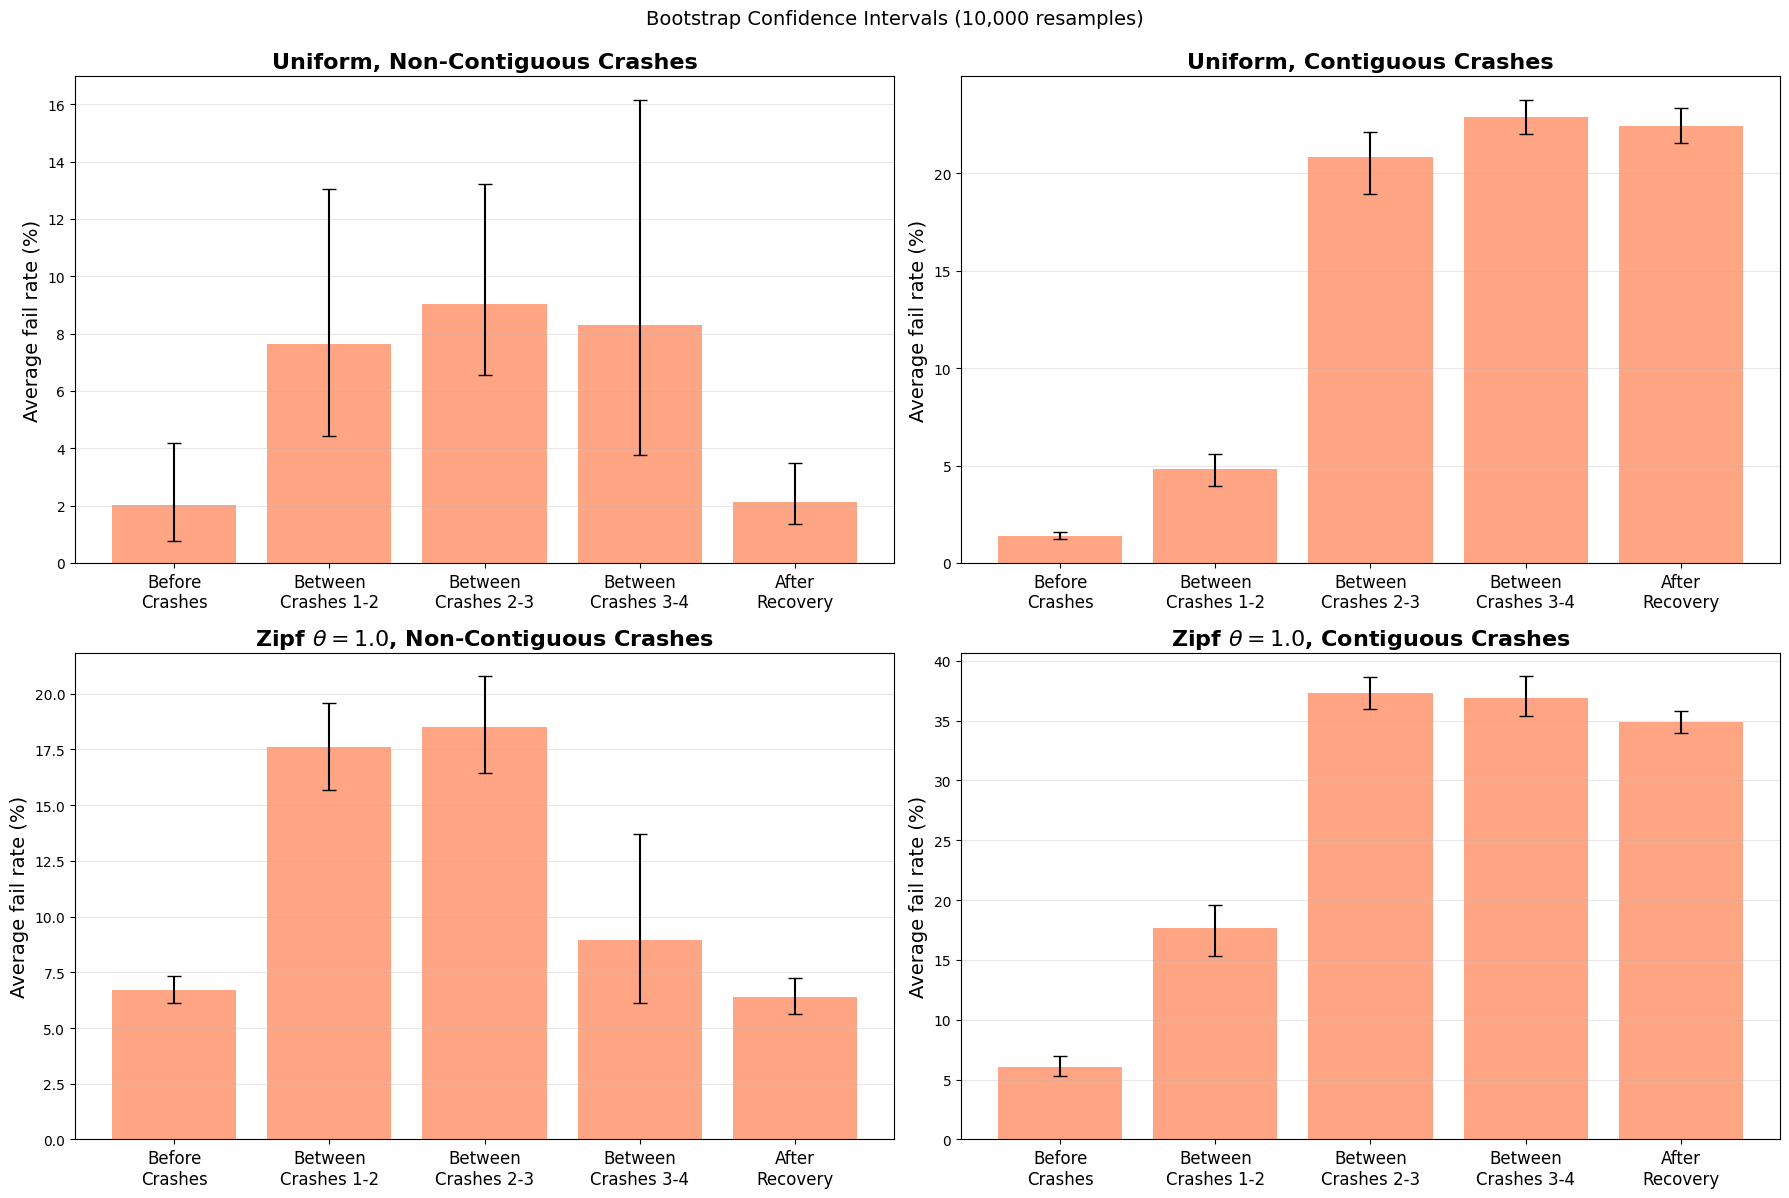


Bootstrap CI Results:

Uniform, Non-Contiguous Crashes:
  Before Crashes: 2.03% [Bootstrap CI: 0.79% - 4.20%]
  Between Crashes 1-2: 7.63% [Bootstrap CI: 4.44% - 13.04%]
  Between Crashes 2: 9.03% [Bootstrap CI: 6.56% - 13.22%]
  Between Crashes 3: 8.30% [Bootstrap CI: 3.76% - 16.16%]
  After Recovery: 2.12% [Bootstrap CI: 1.36% - 3.49%]

Uniform, Contiguous Crashes:
  Before Crashes: 1.39% [Bootstrap CI: 1.21% - 1.57%]
  Between Crashes 1-2: 4.83% [Bootstrap CI: 3.92% - 5.61%]
  Between Crashes 2: 20.81% [Bootstrap CI: 18.95% - 22.10%]
  Between Crashes 3: 22.92% [Bootstrap CI: 22.04% - 23.79%]
  After Recovery: 22.44% [Bootstrap CI: 21.53% - 23.35%]

Zipf $\theta=1.0$, Non-Contiguous Crashes:
  Before Crashes: 6.72% [Bootstrap CI: 6.12% - 7.32%]
  Between Crashes 1-2: 17.61% [Bootstrap CI: 15.66% - 19.56%]
  Between Crashes 2: 18.49% [Bootstrap CI: 16.46% - 21.09%]
  Between Crashes 3: 8.95% [Bootstrap CI: 6.14% - 13.71%]
  After Recovery: 6.37% [Bootstrap CI: 5.65% - 7.27%]

Zipf $

In [40]:
# Plot average fail rate across runs split by phases - Bootstrap CI version
all_dirs_fail_data_bootstrap = []

# Add a mapping for configuration names
config_name_map = {
    'Crash2ZipfSorted2Contiguous': 'Zipf $\\theta=1.0$, Contiguous Crashes',
    'Crash2Uniform1NonContigous': 'Uniform, Non-Contiguous Crashes',
    'Crash2ZipfSorted1NonContiguous': 'Zipf $\\theta=1.0$, Non-Contiguous Crashes',
    'Crash2Uniform2Contigous': 'Uniform, Contiguous Crashes',
}

# Customizable phase name mapping
phase_name_map = {
    'before': 'Before\nCrashes',
    'between_1': 'Between\nCrashes 1-2',
    'between_2': 'Between\nCrashes 2-3',
    'between_3': 'Between\nCrashes 3-4',
    'after': 'After\nRecovery',
    'full': 'Full Run'
}

def get_phase_name(phase_type, phase_number=None):
    """Get phase name from the mapping"""
    if phase_type == "before":
        return phase_name_map.get('before', 'Before')
    elif phase_type == "between":
        key = f'between_{phase_number}'
        return phase_name_map.get(key, f"Between {phase_number}")
    elif phase_type == "after":
        return phase_name_map.get('after', 'After')
    else:
        return phase_name_map.get('full', 'Full Run')

def bootstrap_ci(data, n_bootstrap=10000, ci_level=0.95):
    """
    Compute bootstrap confidence interval for the mean.
    
    Parameters:
    - data: array of values
    - n_bootstrap: number of bootstrap samples
    - ci_level: confidence level (default 95%)
    
    Returns:
    - mean, lower_bound, upper_bound
    """
    data = np.array(data)
    n = len(data)
    
    if n <= 1:
        return float(np.mean(data)), float('nan'), float('nan')
    
    # Generate bootstrap samples
    bootstrap_means = np.zeros(n_bootstrap)
    for i in range(n_bootstrap):
        bootstrap_sample = np.random.choice(data, size=n, replace=True)
        bootstrap_means[i] = np.mean(bootstrap_sample)
    
    # Compute percentiles for CI
    alpha = 1 - ci_level
    lower_percentile = (alpha / 2) * 100
    upper_percentile = (1 - alpha / 2) * 100
    
    mean = float(np.mean(data))
    lower_bound = float(np.percentile(bootstrap_means, lower_percentile))
    upper_bound = float(np.percentile(bootstrap_means, upper_percentile))
    
    return mean, lower_bound, upper_bound

for dir in DATA_DIR.iterdir():
    if not dir.is_dir():
        continue
    runs_data = []
    
    # Collect data for each run
    for run_dir in dir.iterdir():
        if not run_dir.is_dir():
            continue
        csv_path = run_dir / "summary.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        
        # Parse timestamps
        df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
        run_start = df["ts_start"].min()
        
        # Calculate time since run start
        df["time_s"] = (df["ts_end"] - run_start).dt.total_seconds()
        
        # Filter: remove first 70s and keep only up to 600s
        df_filtered = df[(df["time_s"] >= 70.0) & (df["time_s"] <= 600.0)].copy()
        df_filtered["time_s"] = df_filtered["time_s"] - 70.0
        
        # Get maintenance events
        maintenance_events = []
        if "op" in df.columns:
            maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
            maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
            
            if len(maint_start) > 0:
                maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds() - 70.0
                maintenance_events.extend([("START", t) for t in maint_start["time_s"] if 0 <= t <= 530])
            
            if len(maint_end) > 0:
                maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds() - 70.0
                maintenance_events.extend([("END", t) for t in maint_end["time_s"] if 0 <= t <= 530])
        
        maintenance_events.sort(key=lambda x: x[1])
        
        runs_data.append({
            'name': run_dir.name,
            'df': df_filtered,
            'maintenance_events': maintenance_events
        })
    
    if not runs_data:
        continue
    
    # Apply name mapping
    display_name = config_name_map.get(dir.name, dir.name)
    
    all_dirs_fail_data_bootstrap.append({
        'dir_name': display_name,
        'runs_data': runs_data
    })

# Create a single figure with 4 subplots (2x2 grid)
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

for idx, dir_data in enumerate(all_dirs_fail_data_bootstrap):
    if idx >= 4:
        break
    
    ax = axes[idx]
    runs_data = dir_data['runs_data']
    dir_name = dir_data['dir_name']
    
    # Define time slots based on maintenance events
    time_slots = []
    slot_names = []
    
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        
        first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
        if first_start_idx is not None:
            time_slots.append((0.0, events[first_start_idx][1]))
            slot_names.append(get_phase_name("before"))
            
            between_count = 1
            for i in range(len(events) - 1):
                if events[i][0] == "END" and events[i+1][0] == "START":
                    time_slots.append((events[i][1], events[i+1][1]))
                    slot_names.append(get_phase_name("between", between_count))
                    between_count += 1
            
            last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
            if last_end_idx is not None:
                max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
                time_slots.append((events[last_end_idx][1], max_time))
                slot_names.append(get_phase_name("after"))
    else:
        max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
        time_slots.append((0.0, max_time))
        slot_names.append(get_phase_name("full"))
    
    # Compute fail rate for each slot across runs using bootstrap CI
    slot_fail_rates = []
    
    for slot_idx, (t_start, t_end) in enumerate(time_slots):
        run_fail_rates = []
        
        for rd in runs_data:
            df_slot = rd['df'][(rd['df']['time_s'] >= t_start) & (rd['df']['time_s'] < t_end)]
            
            if len(df_slot) > 0:
                fail_rate = (1 - df_slot['success'].mean()) * 100  # Convert to percentage
                run_fail_rates.append(fail_rate)
            else:
                run_fail_rates.append(0.0)
        
        # Use bootstrap CI instead of t-distribution
        mean_fail, lower_bound, upper_bound = bootstrap_ci(np.array(run_fail_rates))
        
        slot_fail_rates.append({
            'slot_name': slot_names[slot_idx],
            'mean': mean_fail,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })
    
    # Plot fail rate by slot with bootstrap CI
    x_pos = np.arange(len(slot_fail_rates))
    means = np.array([s['mean'] for s in slot_fail_rates])
    lower_bounds = np.array([s['lower_bound'] for s in slot_fail_rates])
    upper_bounds = np.array([s['upper_bound'] for s in slot_fail_rates])
    labels = [s['slot_name'] for s in slot_fail_rates]
    
    # Clip confidence intervals to valid range [0, 100] for percentages
    lower_bounds = np.maximum(lower_bounds, 0)
    upper_bounds = np.minimum(upper_bounds, 100)
    
    # Calculate asymmetric error bars
    lower_errors = means - lower_bounds  # How much to subtract from mean
    upper_errors = upper_bounds - means  # How much to add to mean
    
    ax.bar(x_pos, means, alpha=0.7, color='coral')
    ax.errorbar(x_pos, means, yerr=[lower_errors, upper_errors], 
                fmt='none', capsize=5, color='black', linewidth=1.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=12)
    ax.set_ylabel("Average fail rate (%)", fontsize=14)
    ax.set_title(dir_name, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    ax.set_ylim(bottom=0)  # Ensure y-axis starts at 0

plt.suptitle("Bootstrap Confidence Intervals (10,000 resamples)", fontsize=14, y=0.995)
plt.tight_layout()
plt.savefig("crash_recovery_fail_rate_bootstrap.png")
plt.show()

# Print summary for all configurations
print("\nBootstrap CI Results:")
for dir_data in all_dirs_fail_data_bootstrap:
    print(f"\n{dir_data['dir_name']}:")
    runs_data = dir_data['runs_data']
    
    # Recompute slots for printing
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
        
        if first_start_idx is not None:
            time_slots = [(0.0, events[first_start_idx][1])]
            slot_names_print = ["Before Crashes"]
            
            between_count = 1
            for i in range(len(events) - 1):
                if events[i][0] == "END" and events[i+1][0] == "START":
                    time_slots.append((events[i][1], events[i+1][1]))
                    if between_count == 1:
                        slot_names_print.append("Between Crashes 1-2")
                    else:
                        slot_names_print.append(f"Between Crashes {between_count}")
                    between_count += 1
            
            last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
            if last_end_idx is not None:
                max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
                time_slots.append((events[last_end_idx][1], max_time))
                slot_names_print.append("After Recovery")
            
            for slot_idx, (t_start, t_end) in enumerate(time_slots):
                run_fail_rates = []
                for rd in runs_data:
                    df_slot = rd['df'][(rd['df']['time_s'] >= t_start) & (rd['df']['time_s'] < t_end)]
                    if len(df_slot) > 0:
                        fail_rate = (1 - df_slot['success'].mean()) * 100
                        run_fail_rates.append(fail_rate)
                    else:
                        run_fail_rates.append(0.0)
                
                mean_fail, lower_bound, upper_bound = bootstrap_ci(np.array(run_fail_rates))
                # Clip CI bounds for printing
                lower_bound = max(lower_bound, 0)
                upper_bound = min(upper_bound, 100)
                print(f"  {slot_names_print[slot_idx]}: {mean_fail:.2f}% [Bootstrap CI: {lower_bound:.2f}% - {upper_bound:.2f}%]")

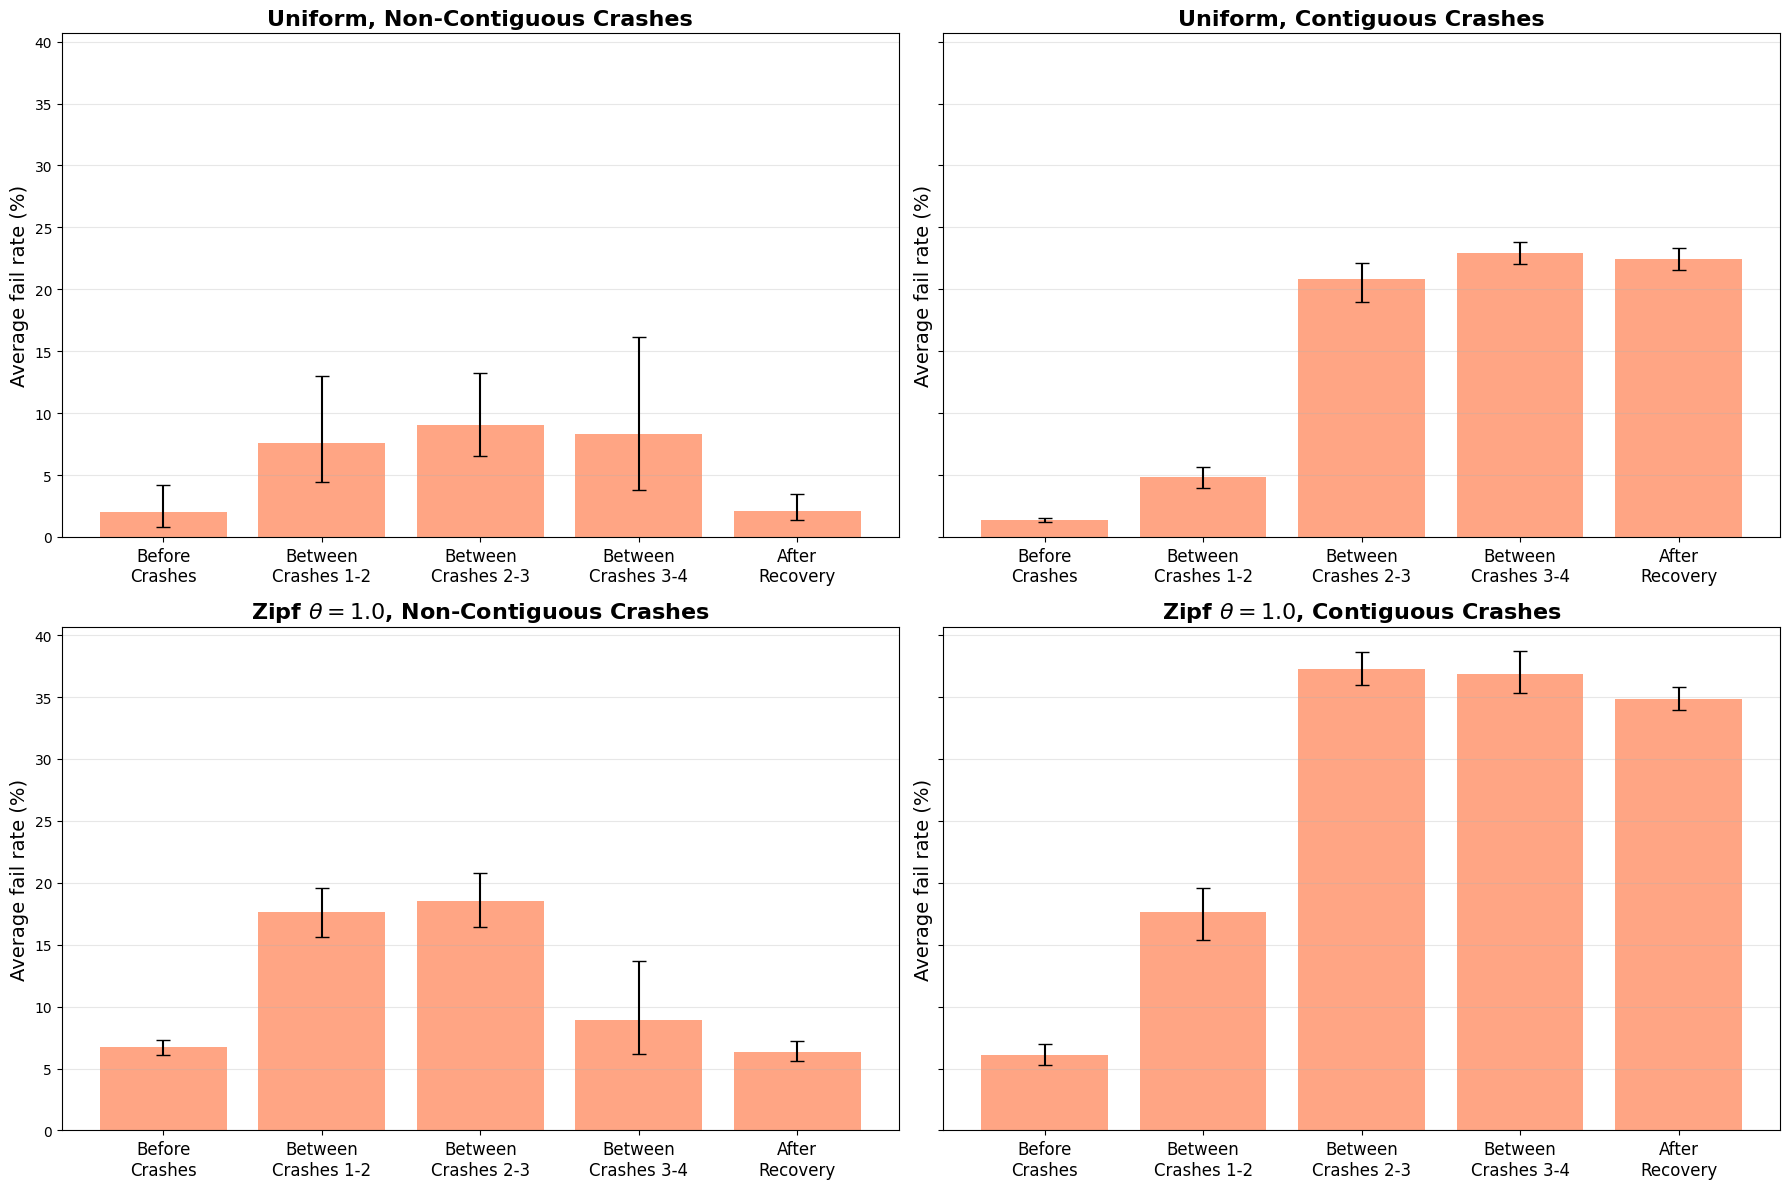

In [46]:
# Create a single figure with 4 subplots (2x2 grid) using bootstrap CI
fig, axes = plt.subplots(2, 2, figsize=(18, 12), sharey=True)
axes = axes.flatten()

for idx, dir_data in enumerate(all_dirs_fail_data_bootstrap):
    if idx >= 4:
        break
    
    ax = axes[idx]
    runs_data = dir_data['runs_data']
    dir_name = dir_data['dir_name']
    
    # Define time slots based on maintenance events
    time_slots = []
    slot_names = []
    
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        
        first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
        if first_start_idx is not None:
            time_slots.append((0.0, events[first_start_idx][1]))
            slot_names.append(get_phase_name("before"))
            
            between_count = 1
            for i in range(len(events) - 1):
                if events[i][0] == "END" and events[i+1][0] == "START":
                    time_slots.append((events[i][1], events[i+1][1]))
                    slot_names.append(get_phase_name("between", between_count))
                    between_count += 1
            
            last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
            if last_end_idx is not None:
                max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
                time_slots.append((events[last_end_idx][1], max_time))
                slot_names.append(get_phase_name("after"))
    else:
        max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
        time_slots.append((0.0, max_time))
        slot_names.append(get_phase_name("full"))
    
    # Compute fail rate for each slot across runs using bootstrap CI
    slot_fail_rates = []
    
    for slot_idx, (t_start, t_end) in enumerate(time_slots):
        run_fail_rates = []
        
        for rd in runs_data:
            df_slot = rd['df'][(rd['df']['time_s'] >= t_start) & (rd['df']['time_s'] < t_end)]
            
            if len(df_slot) > 0:
                fail_rate = (1 - df_slot['success'].mean()) * 100
                run_fail_rates.append(fail_rate)
            else:
                run_fail_rates.append(0.0)
        
        # Use bootstrap CI
        mean_fail, lower_bound, upper_bound = bootstrap_ci(np.array(run_fail_rates))
        
        slot_fail_rates.append({
            'slot_name': slot_names[slot_idx],
            'mean': mean_fail,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound
        })
    
    # Plot fail rate by slot with bootstrap CI
    x_pos = np.arange(len(slot_fail_rates))
    means = np.array([s['mean'] for s in slot_fail_rates])
    lower_bounds = np.array([s['lower_bound'] for s in slot_fail_rates])
    upper_bounds = np.array([s['upper_bound'] for s in slot_fail_rates])
    labels = [s['slot_name'] for s in slot_fail_rates]
    
    # # Clip confidence intervals to valid range [0, 100] for percentages
    # lower_bounds = np.maximum(lower_bounds, 0)
    # upper_bounds = np.minimum(upper_bounds, 100)
    
    # Calculate asymmetric error bars
    lower_errors = means - lower_bounds
    upper_errors = upper_bounds - means
    
    ax.bar(x_pos, means, alpha=0.7, color='coral')
    ax.errorbar(x_pos, means, yerr=[lower_errors, upper_errors], 
                fmt='none', capsize=5, color='black', linewidth=1.5)
    
    ax.set_xticks(x_pos)
    ax.set_xticklabels(labels, rotation=0, ha='center', fontsize=12)
    ax.set_ylabel("Average fail rate (%)", fontsize=14)
    ax.set_title(dir_name, fontsize=16, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')
    # ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig("crash_recovery_fail_rate_bootstrap.png")
plt.show()

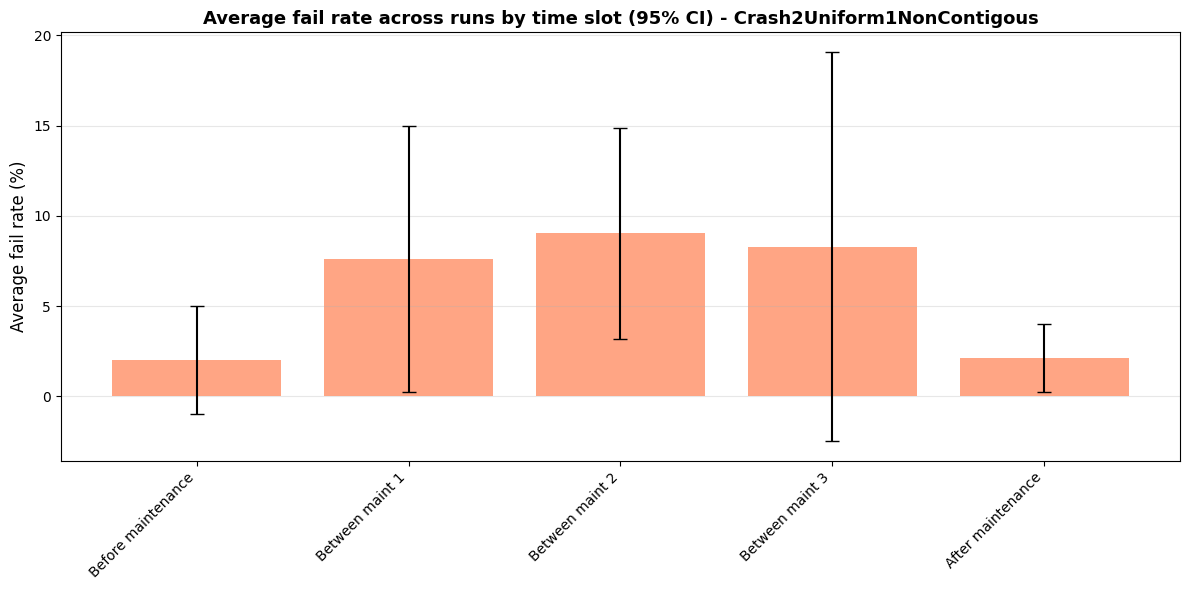


Crash2Uniform1NonContigous - Average fail rate by slot:
  Before maintenance: 2.03% ± 3.00%
  Between maint 1: 7.63% ± 7.36%
  Between maint 2: 9.03% ± 5.82%
  Between maint 3: 8.30% ± 10.79%
  After maintenance: 2.12% ± 1.89%


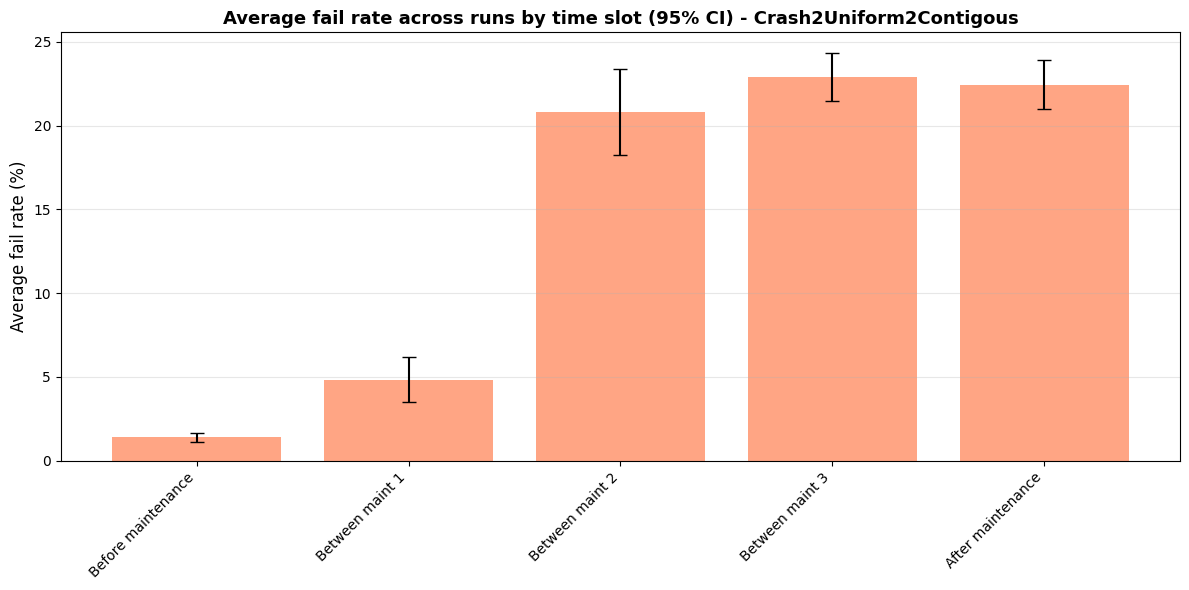


Crash2Uniform2Contigous - Average fail rate by slot:
  Before maintenance: 1.39% ± 0.28%
  Between maint 1: 4.83% ± 1.35%
  Between maint 2: 20.81% ± 2.57%
  Between maint 3: 22.92% ± 1.43%
  After maintenance: 22.44% ± 1.48%


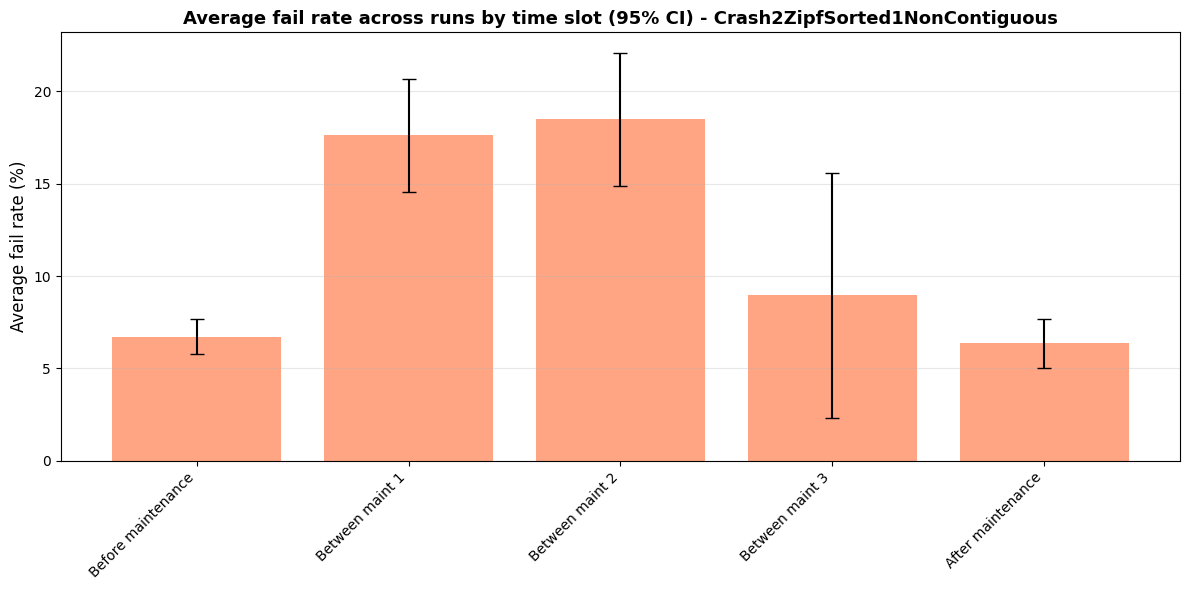


Crash2ZipfSorted1NonContiguous - Average fail rate by slot:
  Before maintenance: 6.72% ± 0.94%
  Between maint 1: 17.61% ± 3.08%
  Between maint 2: 18.49% ± 3.60%
  Between maint 3: 8.95% ± 6.64%
  After maintenance: 6.37% ± 1.33%


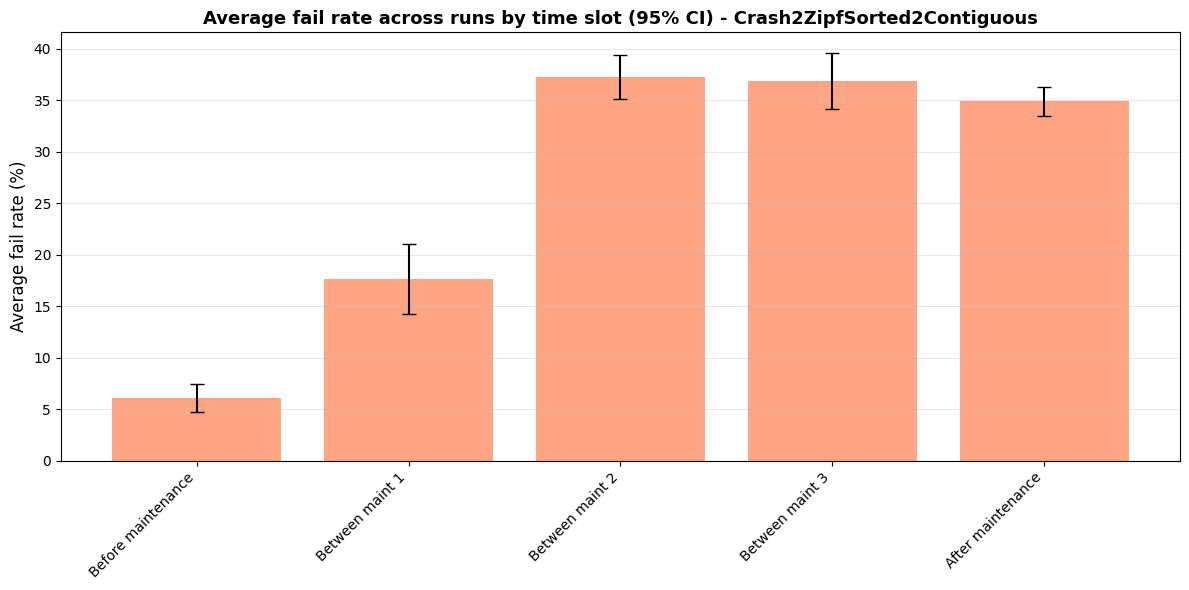


Crash2ZipfSorted2Contiguous - Average fail rate by slot:
  Before maintenance: 6.09% ± 1.33%
  Between maint 1: 17.66% ± 3.39%
  Between maint 2: 37.28% ± 2.12%
  Between maint 3: 36.89% ± 2.72%
  After maintenance: 34.88% ± 1.45%


In [39]:
# Plot average fail rate across runs split by phases
for dir in DATA_DIR.iterdir():
    if not dir.is_dir():
        continue
    runs_data = []
    
    # Collect data for each run
    for run_dir in dir.iterdir():
        if not run_dir.is_dir():
            continue
        csv_path = run_dir / "summary.csv"
        if not csv_path.exists():
            continue
        df = pd.read_csv(csv_path)
        
        # Parse timestamps
        df["ts_end"] = pd.to_datetime(df["ts_end"], utc=True, errors="coerce")
        df["ts_start"] = pd.to_datetime(df["ts_start"], utc=True, errors="coerce")
        run_start = df["ts_start"].min()
        
        # Calculate time since run start
        df["time_s"] = (df["ts_end"] - run_start).dt.total_seconds()
        
        # Filter: remove first 70s and keep only up to 600s
        df_filtered = df[(df["time_s"] >= 70.0) & (df["time_s"] <= 600.0)].copy()
        df_filtered["time_s"] = df_filtered["time_s"] - 70.0
        
        # Get maintenance events
        maintenance_events = []
        if "op" in df.columns:
            maint_start = df[df["op"] == "START_MAINTENANCE"].copy()
            maint_end = df[df["op"] == "END_MAINTENANCE"].copy()
            
            if len(maint_start) > 0:
                maint_start["time_s"] = (maint_start["ts_end"] - run_start).dt.total_seconds() - 70.0
                maintenance_events.extend([("START", t) for t in maint_start["time_s"] if 0 <= t <= 530])
            
            if len(maint_end) > 0:
                maint_end["time_s"] = (maint_end["ts_end"] - run_start).dt.total_seconds() - 70.0
                maintenance_events.extend([("END", t) for t in maint_end["time_s"] if 0 <= t <= 530])
        
        maintenance_events.sort(key=lambda x: x[1])
        
        runs_data.append({
            'name': run_dir.name,
            'df': df_filtered,
            'maintenance_events': maintenance_events
        })
    
    if not runs_data:
        continue
    
    # Define time slots based on maintenance events
    time_slots = []
    slot_names = []
    
    if len(runs_data) > 0 and len(runs_data[0]['maintenance_events']) > 0:
        events = runs_data[0]['maintenance_events']
        
        first_start_idx = next((i for i, (op, t) in enumerate(events) if op == "START"), None)
        if first_start_idx is not None:
            time_slots.append((0.0, events[first_start_idx][1]))
            slot_names.append("Before maintenance")
            
            for i in range(len(events) - 1):
                if events[i][0] == "END" and events[i+1][0] == "START":
                    time_slots.append((events[i][1], events[i+1][1]))
                    slot_names.append(f"Between maint {len(time_slots)-1}")
            
            last_end_idx = next((len(events) - 1 - i for i, (op, t) in enumerate(reversed(events)) if op == "END"), None)
            if last_end_idx is not None:
                max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
                time_slots.append((events[last_end_idx][1], max_time))
                slot_names.append("After maintenance")
    else:
        max_time = max(rd['df']['time_s'].max() for rd in runs_data if len(rd['df']) > 0)
        time_slots.append((0.0, max_time))
        slot_names.append("Full run")
    
    # Compute fail rate for each slot across runs
    slot_fail_rates = []
    
    for slot_idx, (t_start, t_end) in enumerate(time_slots):
        run_fail_rates = []
        
        for rd in runs_data:
            df_slot = rd['df'][(rd['df']['time_s'] >= t_start) & (rd['df']['time_s'] < t_end)]
            
            if len(df_slot) > 0:
                fail_rate = (1 - df_slot['success'].mean()) * 100  # Convert to percentage
                run_fail_rates.append(fail_rate)
            else:
                run_fail_rates.append(0.0)
        
        mean_fail, half_fail = ci_mean(np.array(run_fail_rates))
        slot_fail_rates.append({
            'slot_name': slot_names[slot_idx],
            'mean': mean_fail,
            'ci_half': half_fail
        })
    
    # Plot fail rate by slot
    plt.figure(figsize=(12, 6))
    x_pos = np.arange(len(slot_fail_rates))
    means = [s['mean'] for s in slot_fail_rates]
    ci_halfs = [s['ci_half'] for s in slot_fail_rates]
    labels = [s['slot_name'] for s in slot_fail_rates]
    
    plt.bar(x_pos, means, yerr=ci_halfs, capsize=5, alpha=0.7, color='coral')
    plt.xticks(x_pos, labels, rotation=45, ha='right')
    plt.ylabel("Average fail rate (%)", fontsize=12)
    plt.title(f"Average fail rate across runs by time slot (95% CI) - {dir.name}", fontsize=13, fontweight='bold')
    plt.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()
    
    # Print summary
    print(f"\n{dir.name} - Average fail rate by slot:")
    for s in slot_fail_rates:
        print(f"  {s['slot_name']}: {s['mean']:.2f}% ± {s['ci_half']:.2f}%")